In [ ]:
from pathlib import Path
import sys

# Make this package's scripts/ importable (exp_info, regions, data_utils, ...).
PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts" / "exp_info.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start this notebook from inside the polar_analysis package.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

In [ ]:
# Parameters: directories and settings for this run. Edit them for another
# machine or experiment, or override with papermill (-p NAME VALUE).
DIAG_DIR = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper/diag_data"  # output diagnostic data
FIG_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper/figures/arctic_amplification/65n_driftcorr"  # output figures

In [9]:
import os, glob
from pathlib import Path
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

In [10]:
class AAPDFPanelPlotter:
    """
    Plot PDFs (density histograms) of Arctic Amplification using *all* samples
    across time × ensemble for multiple groups.

    Expects AA NetCDFs from ArcticAAProcessor with variables:
      - 'aa'        (dims include time and optionally ens)  OR
      - 'aa_mean'   (time-only series; used if 'aa' absent)

    Reference (vertical red line) is taken from ERA5 JSON ('AA_bar_mean') if
    obs_prefix is provided; otherwise use a fixed ref_value.

    Example:
      groups = {
        "CMIP5":  "AA_CMIP5_center_ts_CMIP5_TS",
        "CMIP6":  "AA_CMIP6_center_ts_CMIP6_TS",
        "MPI-GE": "AA_MPI-GE_center_ts_MPI-GE_TS",
        "CanESM5":"AA_CanESM5_center_ts_CanESM5_TS",
      }
      AAPDFPanelPlotter(out_dir=OUT_DIR, trend_window=30, anchor="center").plot(
          season="ANN", groups=groups, obs_prefix="AA_ERA5_center_ts_ERA5_TS",
          out_name="AA_pdf_panels_ANN_center.pdf"
      )
    """

    def __init__(
        self,
        *,
        out_dir,
        trend_window=30,
        anchor="center",
        ptargt=(1979, 2018),
        fontz=12,
        dpi=300,
    ):
        self.out_dir = out_dir
        self.trend_window = int(trend_window)
        self.anchor = str(anchor)
        self.ptargt = tuple(ptargt)
        self.fontz = int(fontz)
        self.dpi = int(dpi)

        plt.rcParams.update({
            "font.size": self.fontz,
            "axes.titlesize": self.fontz * 1.05,
            "axes.labelsize": self.fontz,
            "xtick.labelsize": self.fontz * 0.9,
            "ytick.labelsize": self.fontz * 0.9,
            "legend.fontsize": self.fontz * 0.9,
        })

    # ---------- file helpers ----------
    def _modern_name(self, prefix, season, with_anchor=True, ptargt=None):
        p0, p1 = (ptargt or self.ptargt)
        if with_anchor:
            return f"{prefix}_{season}_{p0}-{p1}_{self.trend_window}yr_{self.anchor}.nc"
        else:
            return f"{prefix}_{season}_{p0}-{p1}_{self.trend_window}yr.nc"

    def _candidate_paths(self, prefix, season):
        p0, p1 = self.ptargt
        alts = [
            os.path.join(self.out_dir, self._modern_name(prefix, season, True, (p0, p1))),
            os.path.join(self.out_dir, self._modern_name(prefix, season, False, (p0, p1))),
        ]
        # a couple of loose fallbacks
        for a, b in [(1979, 2018), (1979, 2050)]:
            alts.append(os.path.join(self.out_dir, self._modern_name(prefix, season, True, (a, b))))
            alts.append(os.path.join(self.out_dir, self._modern_name(prefix, season, False, (a, b))))
        glob_pat = os.path.join(self.out_dir, f"{prefix}_{season}_*_{self.trend_window}yr*.nc")
        return alts + sorted(glob.glob(glob_pat))

    def _open_first_existing(self, prefix, season):
        tried = []
        for p in self._candidate_paths(prefix, season):
            if os.path.exists(p):
                return xr.open_dataset(p), p
            tried.append(p)
        raise FileNotFoundError("No AA file for prefix=%r season=%r\nTried:\n  - %s"
                                % (prefix, season, "\n  - ".join(tried[:10])))

    @staticmethod
    def _json_for_nc(nc_path):
        return nc_path[:-3] + ".json" if nc_path.endswith(".nc") else None

    def _load_ref_from_obs_json(self, obs_nc_path):
        j = self._json_for_nc(obs_nc_path)
        if j and os.path.exists(j):
            with open(j, "r") as f:
                try:
                    s = json.load(f)
                    v = s.get("AA_bar_mean", None)
                    if isinstance(v, (int, float)):
                        return float(v)
                except Exception:
                    pass
        return None

    # ---------- data extraction ----------
    @staticmethod
    def _all_samples(ds) -> np.ndarray:
        """
        Return 1D array of *all* AA samples across time × ensemble.
        Priority order:
          - 'aa' (use all values over its dims)
          - 'aa_mean' (use all time points)
        NaNs are dropped.
        """
        if "aa" in ds:
            arr = np.asarray(ds["aa"].values, dtype=float)
        elif "aa_mean" in ds:
            arr = np.asarray(ds["aa_mean"].values, dtype=float)
        else:
            raise KeyError("Dataset must contain 'aa' or 'aa_mean'.")
        arr = arr.ravel()
        return arr[np.isfinite(arr)]

    # ---------- plotting ----------
    def plot(
        self,
        *,
        season,
        groups: dict,            # {"Panel Title": prefix, ...}
        obs_prefix=None,         # if provided, ref from its JSON (AA_bar_mean)
        ref_value=None,          # used if obs_prefix missing or JSON lacks value
        bins=24,
        xlim=(0, 6),
        ylim=(0, 1.0),
        density=True,
        out_name="AA_pdf_panels.pdf",
        figsize_per_panel=(3.0, 2.5),
        sharey=True,
    ):
        # decide reference value
        ref = None
        if obs_prefix is not None:
            obs_ds, obs_nc = self._open_first_existing(obs_prefix, season)
            try:
                ref = self._load_ref_from_obs_json(obs_nc)
            finally:
                obs_ds.close()

        if ref is None:
            ref = float(ref_value) if ref_value is not None else 2.0  # default gate

        labels = list(groups.keys())
        n = len(labels)

        fig, axes = plt.subplots(
            1, n, figsize=(figsize_per_panel[0]*n, figsize_per_panel[1]),
            dpi=self.dpi, sharey=sharey, squeeze=False
        )
        axes = axes[0]

        for i, lab in enumerate(labels):
            prefix = groups[lab]
            ds, _ = self._open_first_existing(prefix, season)
            try:
                samples = self._all_samples(ds)
            finally:
                ds.close()

            # fraction of all samples ≥ ref
            p = 100.0 * (np.sum(samples >= ref) / samples.size) if samples.size else 0.0

            ax = axes[i]
            ax.hist(samples, bins=bins, density=density, alpha=0.8,
                    edgecolor="black", linewidth=0.6)
            ax.axvline(ref, color="red", lw=1.6, alpha=0.9)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_title(lab)
            ax.set_xlabel("AA")
            if i == 0:
                ax.set_ylabel("Density" if density else "Count")
            ax.text(
                0.04, 0.92,
                f"p = {p:.1f} %\nN = {samples.size}",
                transform=ax.transAxes,
                ha="left", va="top",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9)
            )

            # light grid for readability
            ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.5)

        fig.tight_layout()
        Path(self.out_dir).mkdir(parents=True, exist_ok=True)
        out_path = os.path.join(
            self.out_dir,
            out_name.replace(".pdf", f"_{season}_{self.anchor}.pdf")
        )
        fig.savefig(out_path, dpi=self.dpi, bbox_inches="tight")
        print(f"[OK] saved {out_path}")
        return fig, axes
    
    def plot_all_seasons_one_group(
        self,
        *,
        seasons,
        group_label,
        prefix,              # model prefix, e.g. AA2_driftcorr_E3SMv3-LE_center_ts_...
        obs_prefix=None,     # obs prefix, same pattern but for ERA5
        ref_value=None,      # fallback if JSON missing
        bins=24,
        xlim=(0, 6),
        ylim=(0, 1.0),
        density=True,
        out_name="AA_pdf_all_seasons.pdf",
        figsize_per_panel=(3.0, 2.5),
        sharey=True,
    ):
        """
        Plot one row of panels: each panel is a different season for a single group.
        The reference (red line) is computed separately for each season.
        """
        n = len(seasons)

        fig, axes = plt.subplots(
            1, n,
            figsize=(figsize_per_panel[0] * n, figsize_per_panel[1]),
            dpi=self.dpi,
            sharey=sharey,
            squeeze=False,
        )
        axes = axes[0]

        for i, seas in enumerate(seasons):
            # decide reference value for this season
            ref = None
            if obs_prefix is not None:
                obs_ds, obs_nc = self._open_first_existing(obs_prefix, seas)
                try:
                    ref = self._load_ref_from_obs_json(obs_nc)
                finally:
                    obs_ds.close()

            if ref is None:
                ref = float(ref_value) if ref_value is not None else 2.0

            # load model AA samples for this season
            ds, _ = self._open_first_existing(prefix, seas)
            try:
                samples = self._all_samples(ds)
            finally:
                ds.close()

            p = 100.0 * (np.sum(samples >= ref) / samples.size) if samples.size else 0.0

            ax = axes[i]
            ax.hist(
                samples,
                bins=bins,
                density=density,
                alpha=0.8,
                edgecolor="black",
                linewidth=0.6,
            )
            ax.axvline(ref, color="red", lw=1.6, alpha=0.9)
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.set_title(seas)
            ax.set_xlabel("AA")
            if i == 0:
                ax.set_ylabel("Density" if density else "Count")

            ax.text(
                0.04,
                0.92,
                f"p = {p:.1f} %\nN = {samples.size}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc="white",
                    ec="0.6",
                    alpha=0.9,
                ),
            )
            ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.5)

        # optional group label as a suptitle
        fig.suptitle(group_label, y=1.02, fontsize=self.fontz * 1.1)
        fig.tight_layout()

        Path(self.out_dir).mkdir(parents=True, exist_ok=True)
        out_path = os.path.join(
            self.out_dir,
            out_name.replace(".pdf", f"_{self.anchor}.pdf"),
        )
        fig.savefig(out_path, dpi=self.dpi, bbox_inches="tight")
        print(f"[OK] saved {out_path}")
        return fig, axes


[OK] saved /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_driftcorr_pdf_allseasons_center_center.pdf
[OK] saved ./figures/AA2_driftcorr_pdf_allseasons_center.pdf
[OK] saved /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_driftcorr_pdf_allseasons_start_start.pdf
[OK] saved ./figures/AA2_driftcorr_pdf_allseasons_start.pdf
[OK] saved /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_driftcorr_pdf_allseasons_end_end.pdf
[OK] saved ./figures/AA2_driftcorr_pdf_allseasons_end.pdf








In [12]:
if __name__ == "__main__":
    # ---- paths / constants ----
    OUT_DIR   = DIAG_DIR   # where AA_*.nc/.json live
    os.makedirs(FIG_DIR, exist_ok=True)
    
    region_dict = {
        "arctic": {"name": "Arctic2", "lat_range": (66.5, 90.0),  "lon_range": (-180, 180)},
        "global": {"name": "global", "lat_range": (-90.0, 90.0), "lon_range": (-180, 180)},
    }
    
    VAR          = "TS"
    PTARGT       = (1979, 2018)     # keep consistent with processor outputs
    SEASONS      = ["ANN", "DJF", "MAM", "JJA", "SON"]
    ANCHORS      = ["center", "start", "end"]
    TREND_WINDOW = 30
    
    fontz = 24
    dpi   = 300
    ref_value = 2.0
    bins  = 24
    xlim  = (0.5, 7)
    ylim  = (0, 1.0)
    density = True
    figsize_per_panel = (8, 6)   # per-season panel size; total width = 8 * len(SEASONS)
    anchor = "center"            # initial, overwritten in loop

    # ---- instantiate the PDF plotter ----
    plotter = AAPDFPanelPlotter(
        out_dir=OUT_DIR,
        trend_window=TREND_WINDOW,
        anchor=anchor,
        ptargt=PTARGT,
        fontz=fontz,
        dpi=dpi,
    )

    for anch in ANCHORS:
        plotter.anchor = anch  # affects filename resolution & output suffix

        # prefixes must match processor naming
        obs_prefix = f"AA2_driftcorr_ERA5_{anch}_ts_ERA5_{VAR}"
        mod_prefix = f"AA2_driftcorr_E3SMv3-LE_{anch}_ts_v3.LR.historical_{VAR}"

        out_basename = f"AA2_driftcorr_pdf_allseasons_{anch}.pdf"

        fig, axes = plotter.plot_all_seasons_one_group(
            seasons=SEASONS,
            group_label="E3SMv3-LE",
            prefix=mod_prefix,
            obs_prefix=obs_prefix,
            ref_value=ref_value,
            bins=bins,
            xlim=xlim,
            ylim=ylim,
            density=density,
            out_name=out_basename,       # saved into OUT_DIR first
            figsize_per_panel=figsize_per_panel,
        )

        # Move from OUT_DIR → FIG_DIR (keeps all final figs together)
        src = os.path.join(OUT_DIR, out_basename.replace(".pdf", f"_{anch}.pdf"))
        dst = os.path.join(FIG_DIR, out_basename)
        if os.path.exists(src):
            Path(src).replace(dst)
            print(f"[OK] saved {dst}")


[OK] saved /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_driftcorr_pdf_panels_ANN_center_ANN_center.pdf
[OK] saved ./figures/AA2_driftcorr_pdf_panels_ANN_center.pdf
[OK] saved /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_driftcorr_pdf_panels_DJF_center_DJF_center.pdf
[OK] saved ./figures/AA2_driftcorr_pdf_panels_DJF_center.pdf
[OK] saved /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_driftcorr_pdf_panels_MAM_center_MAM_center.pdf
[OK] saved ./figures/AA2_driftcorr_pdf_panels_MAM_center.pdf
[OK] saved /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_driftcorr_pdf_panels_JJA_center_JJA_center.pdf
[OK] saved ./figures/AA2_driftcorr_pdf_panels_JJA_center.pdf
[OK] saved /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_driftcorr_pdf_panels_SON_center_SON_center.pdf
[OK] saved ./figures/AA2_driftcorr_pdf_panels_SON_center.pdf


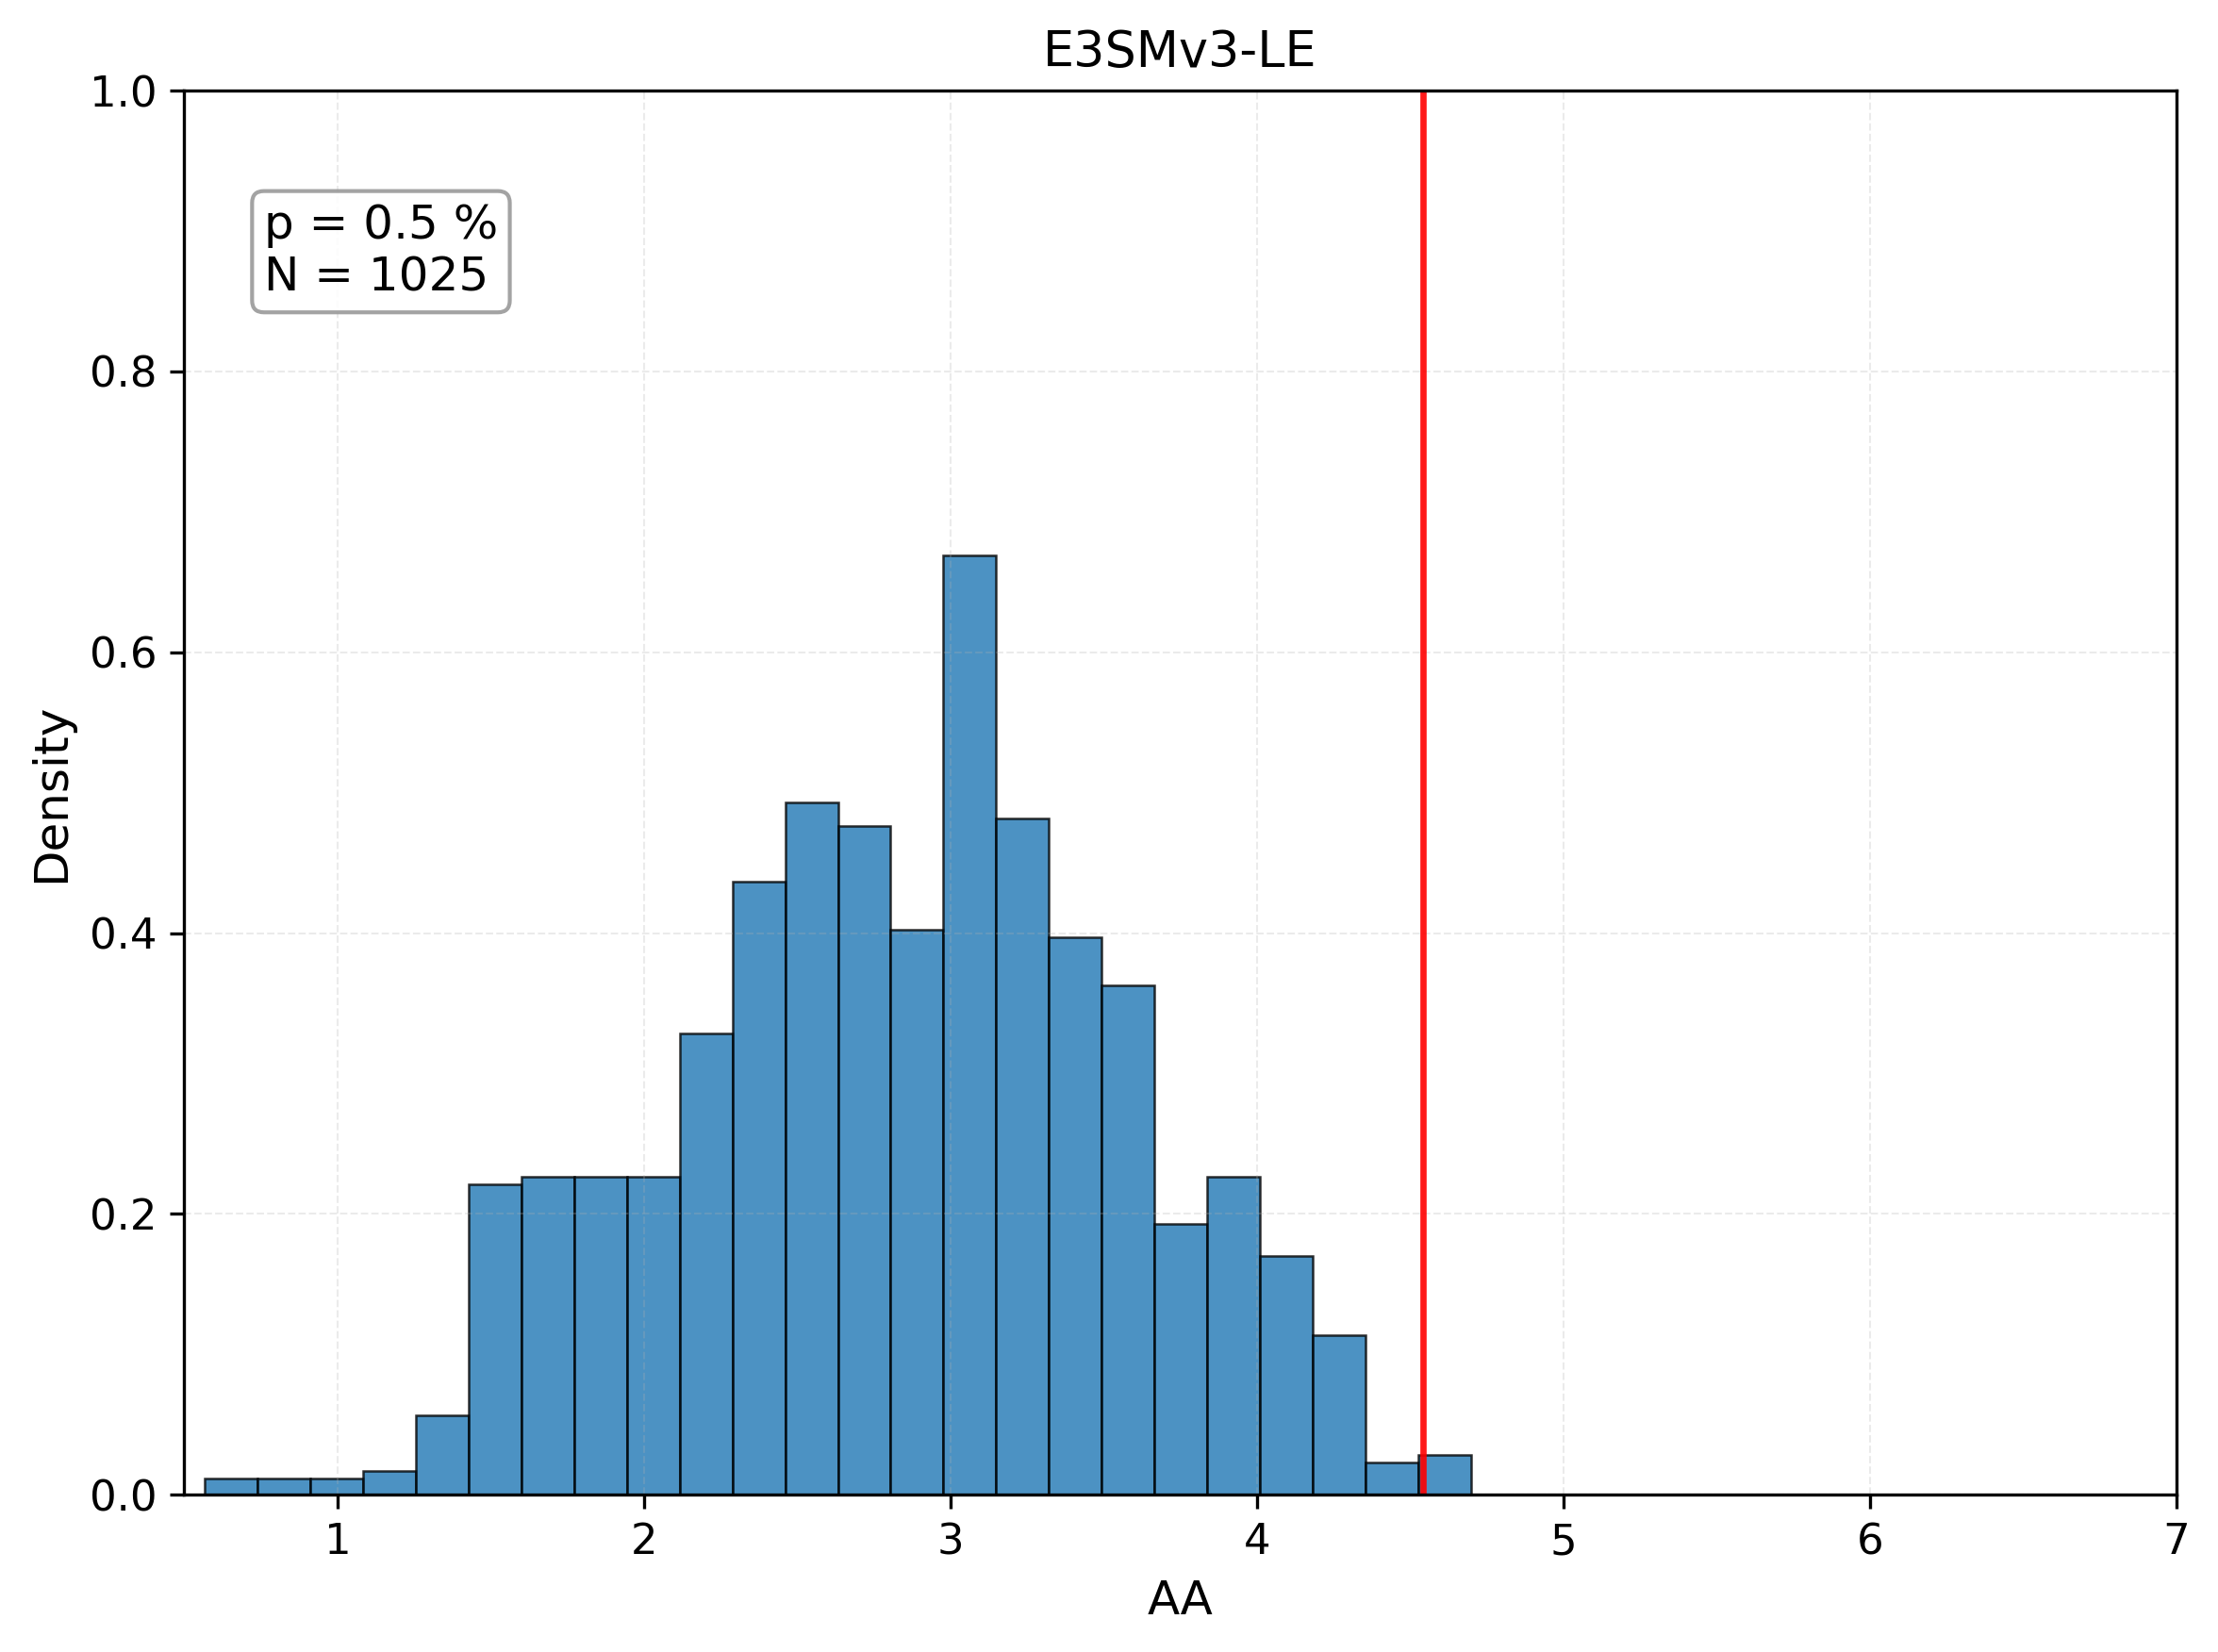

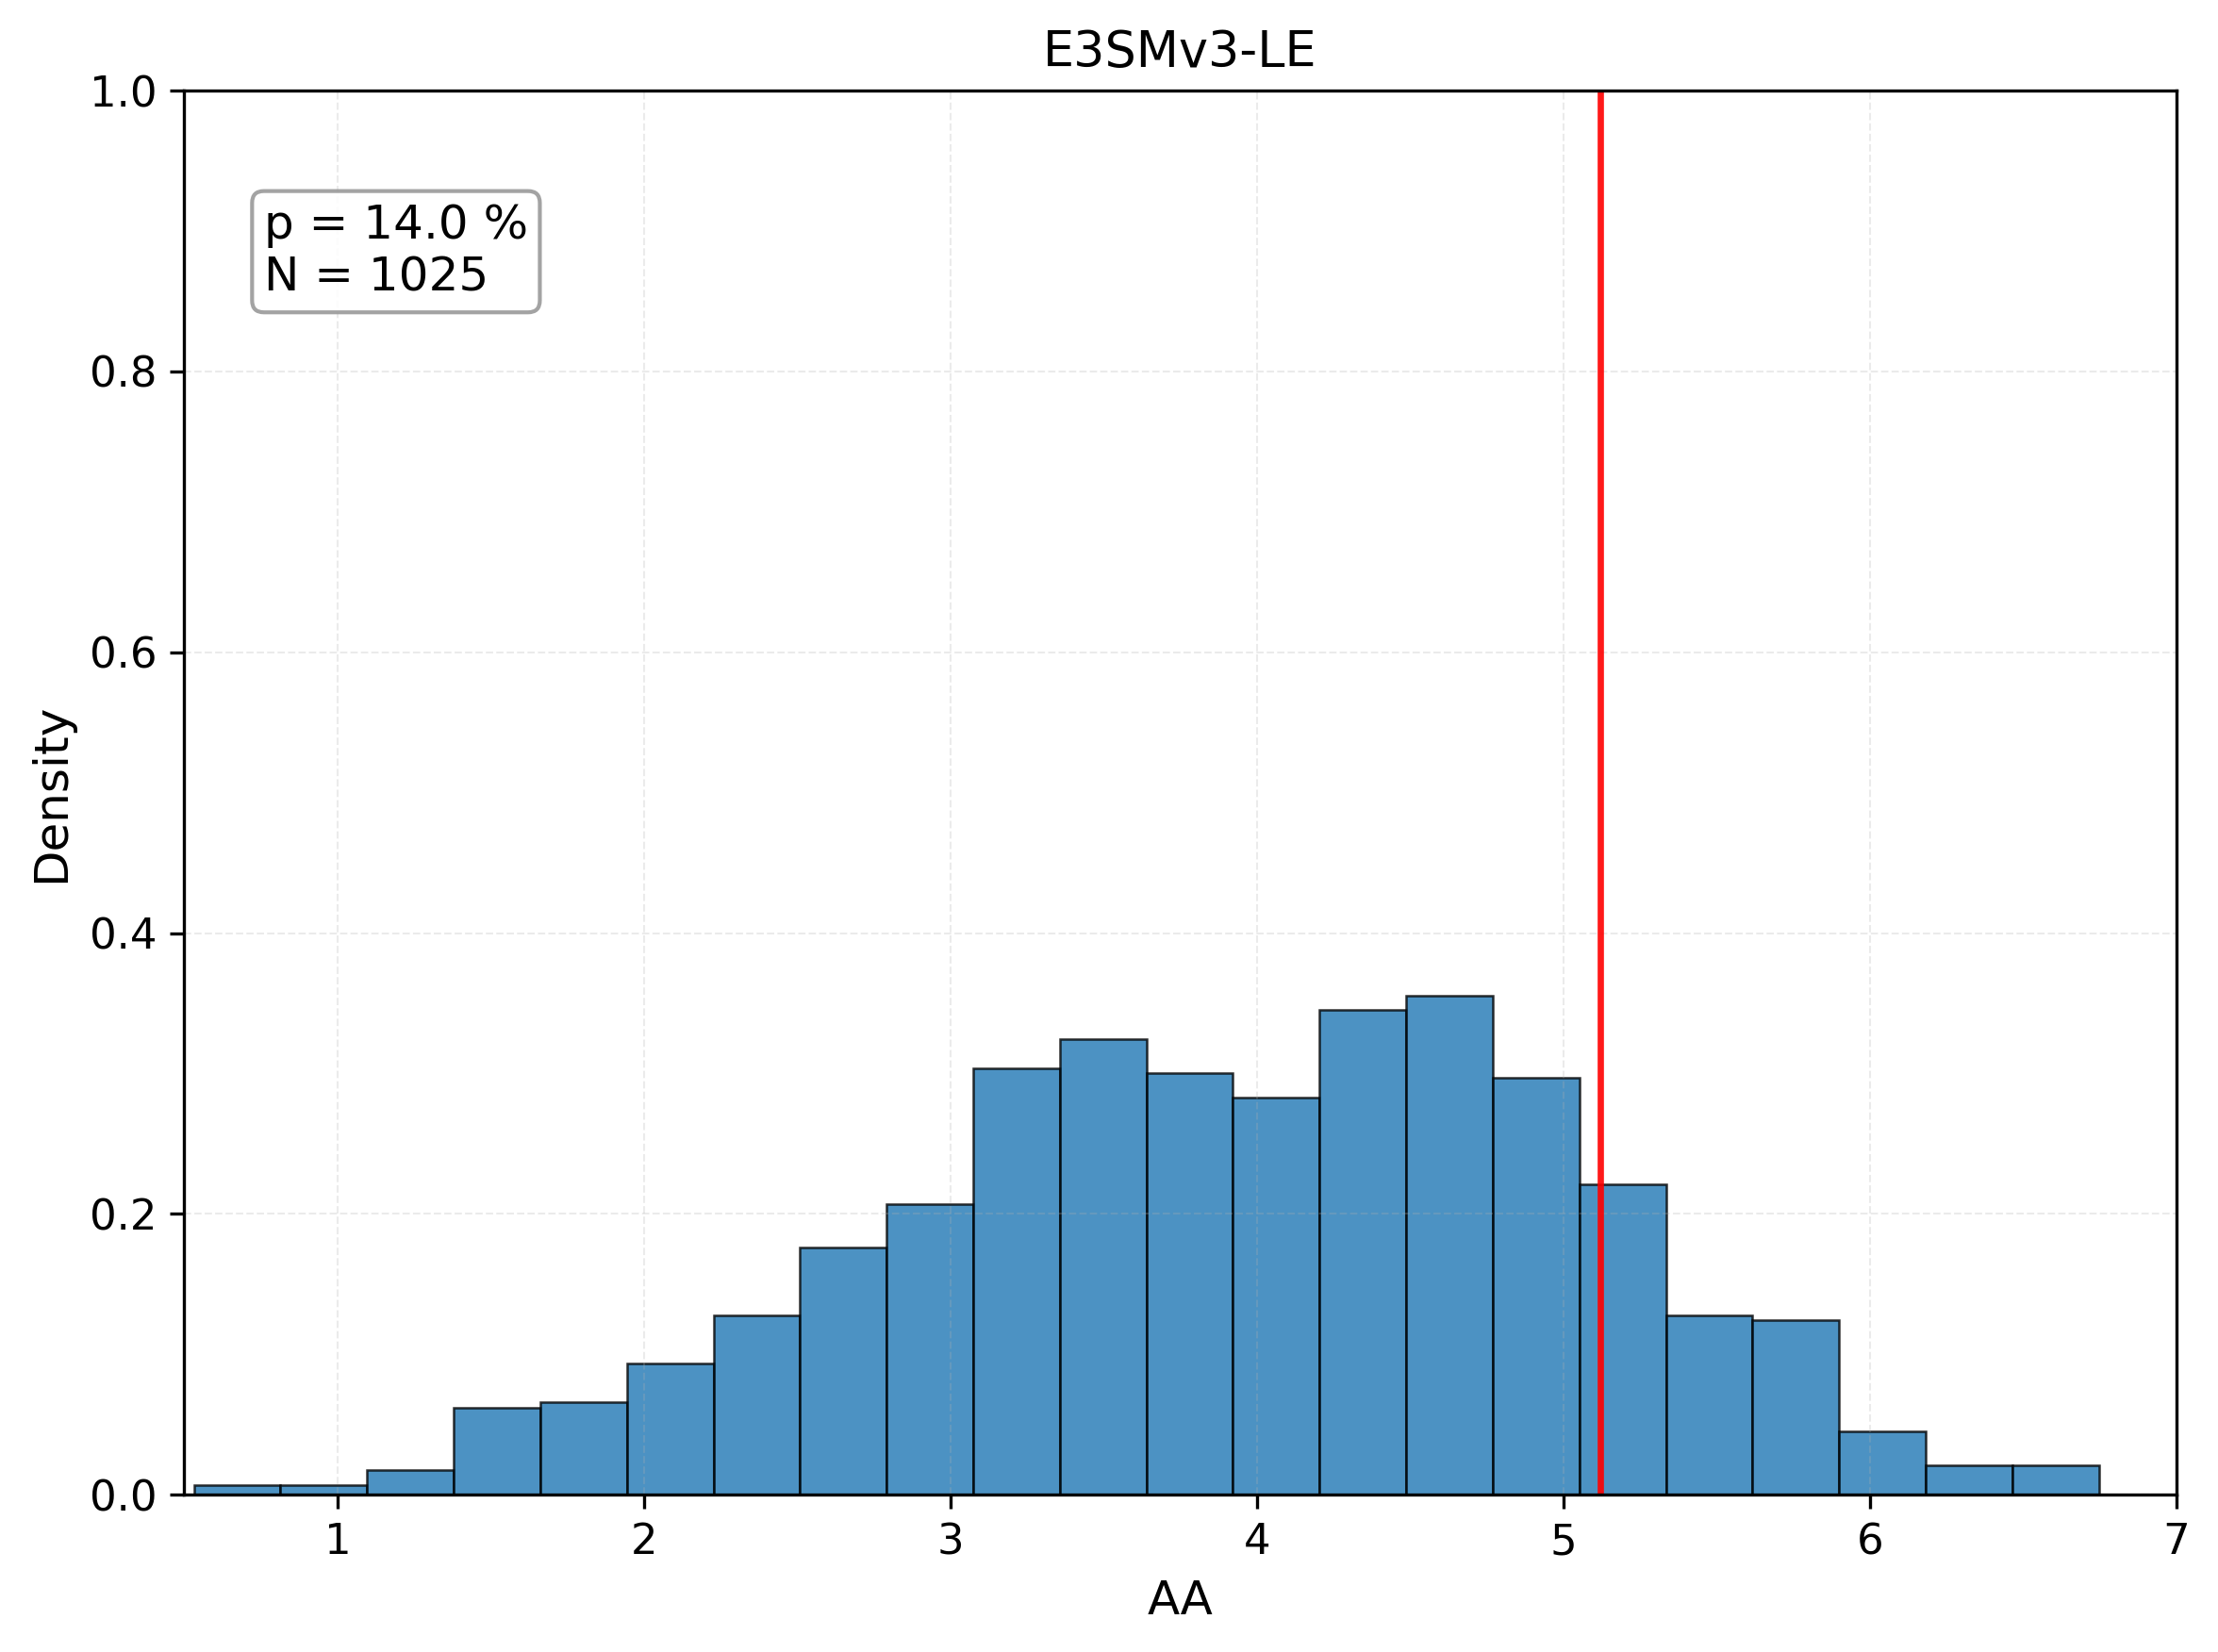

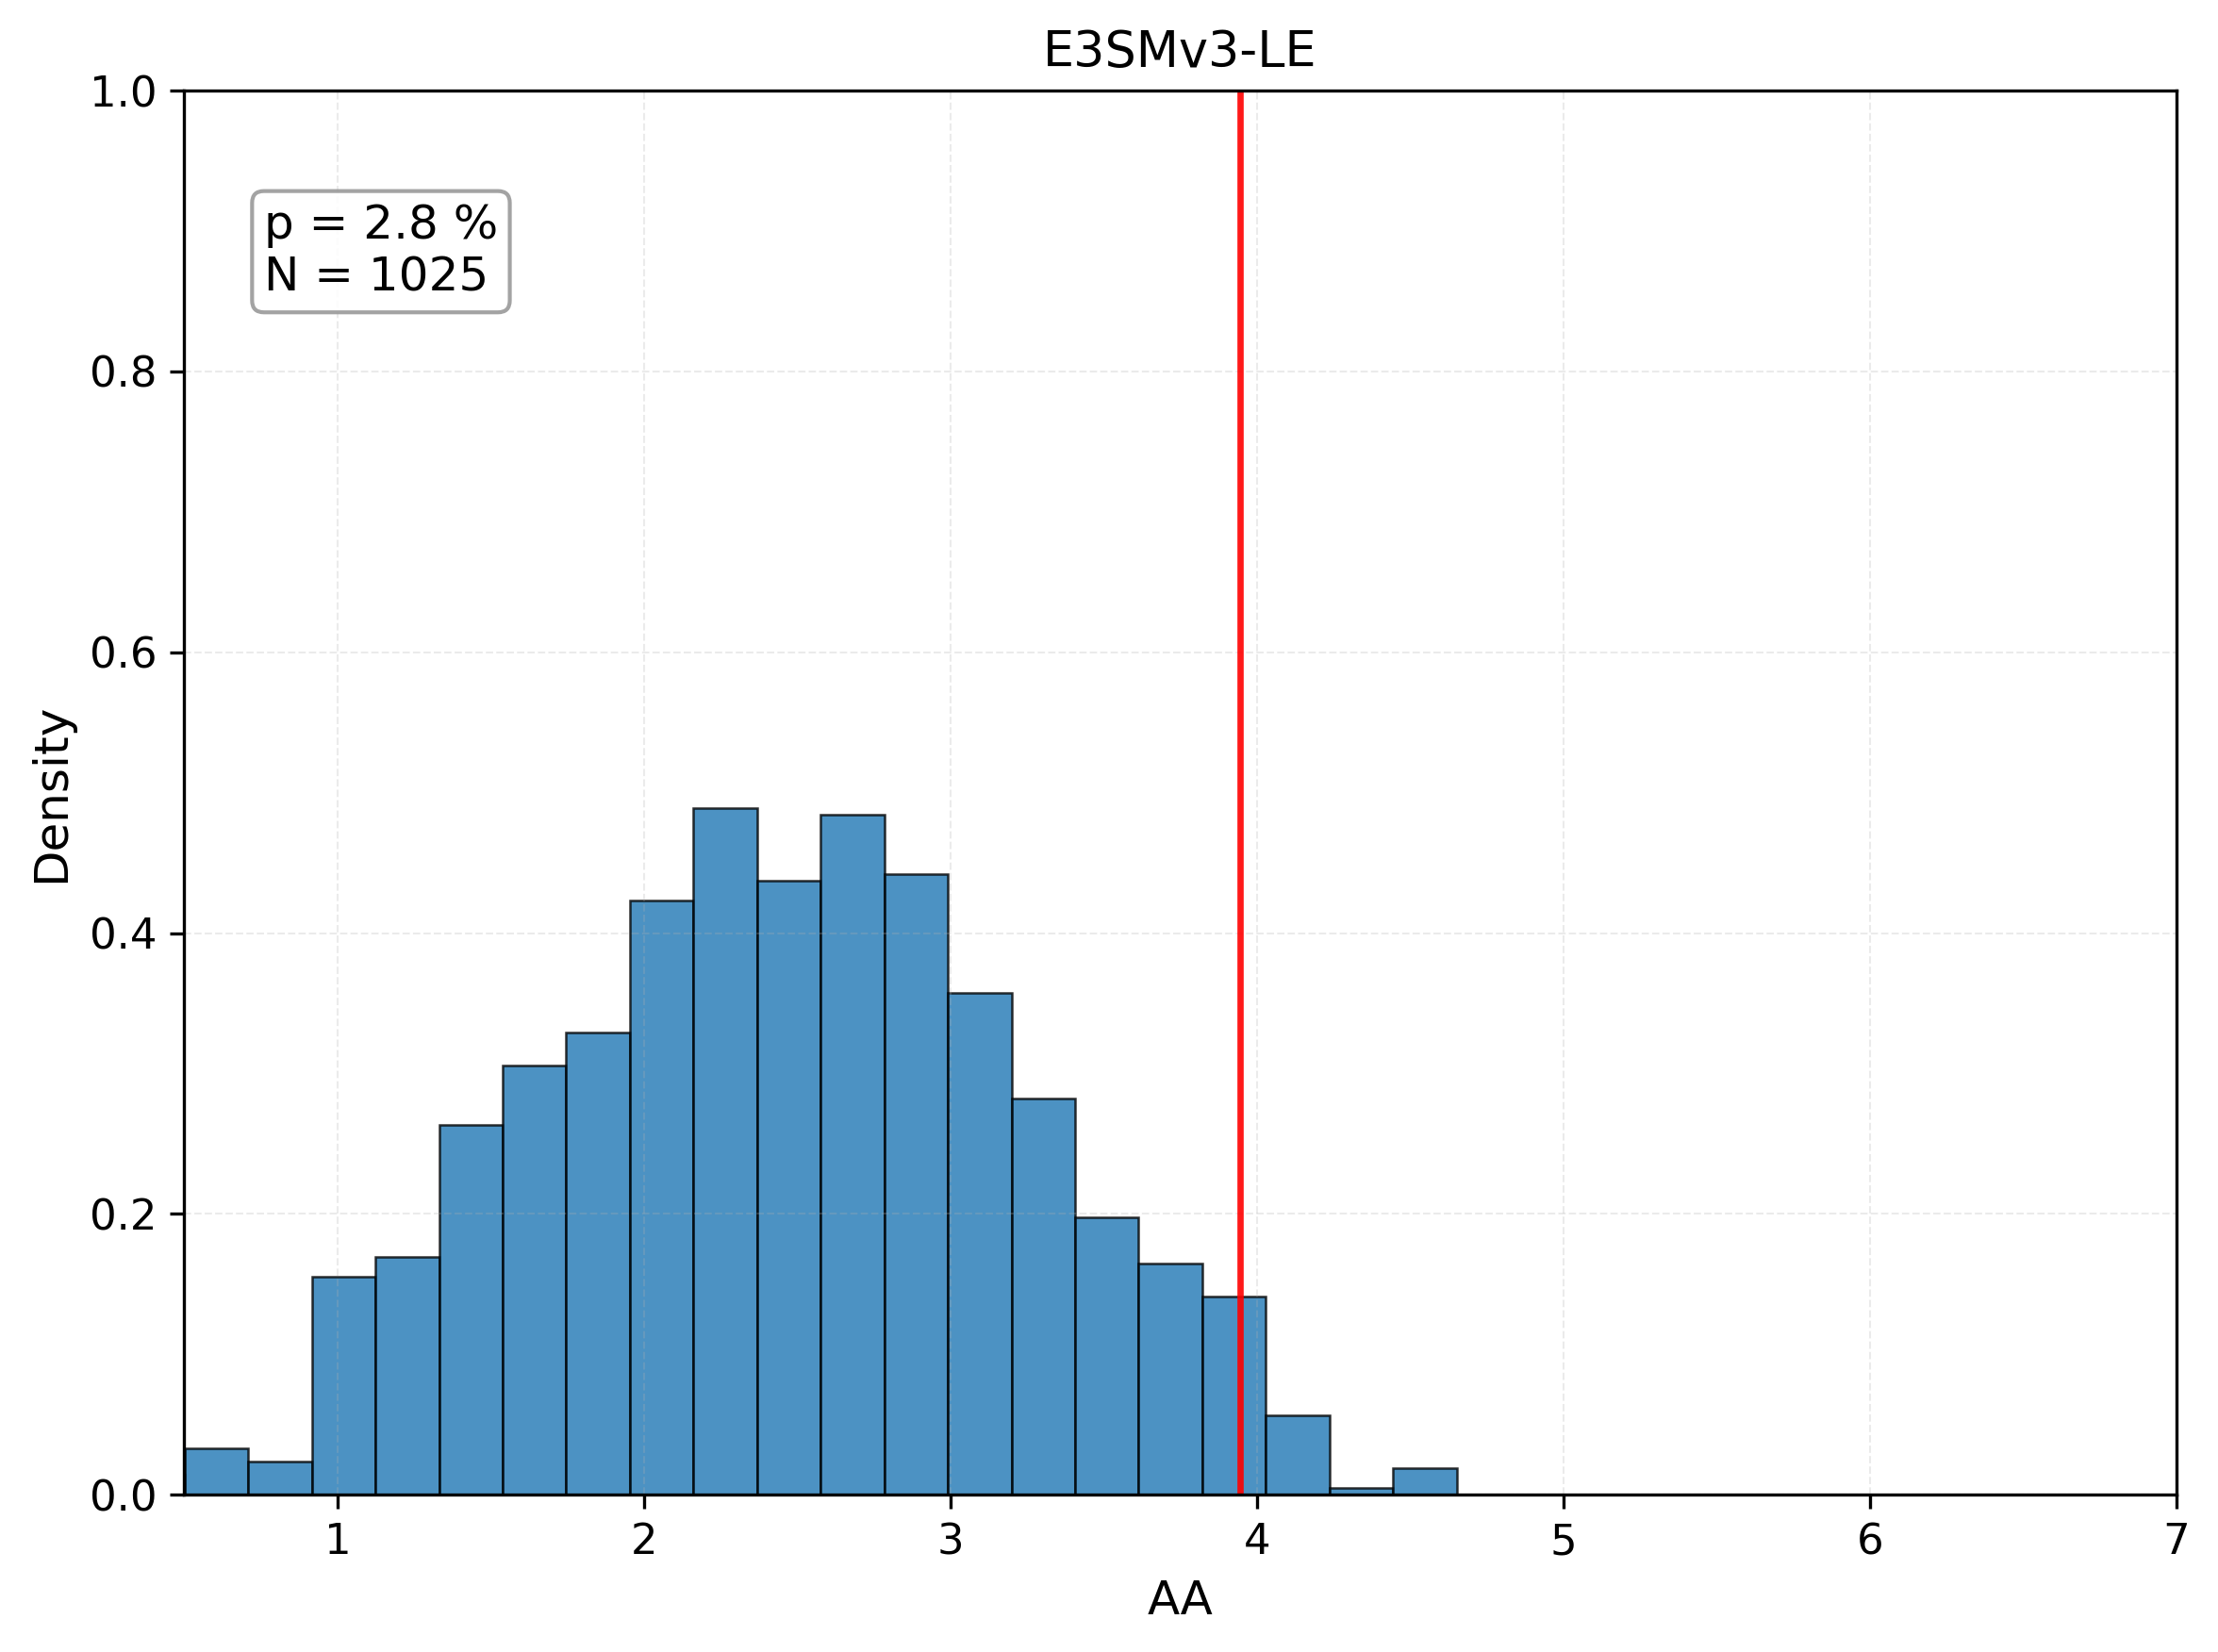

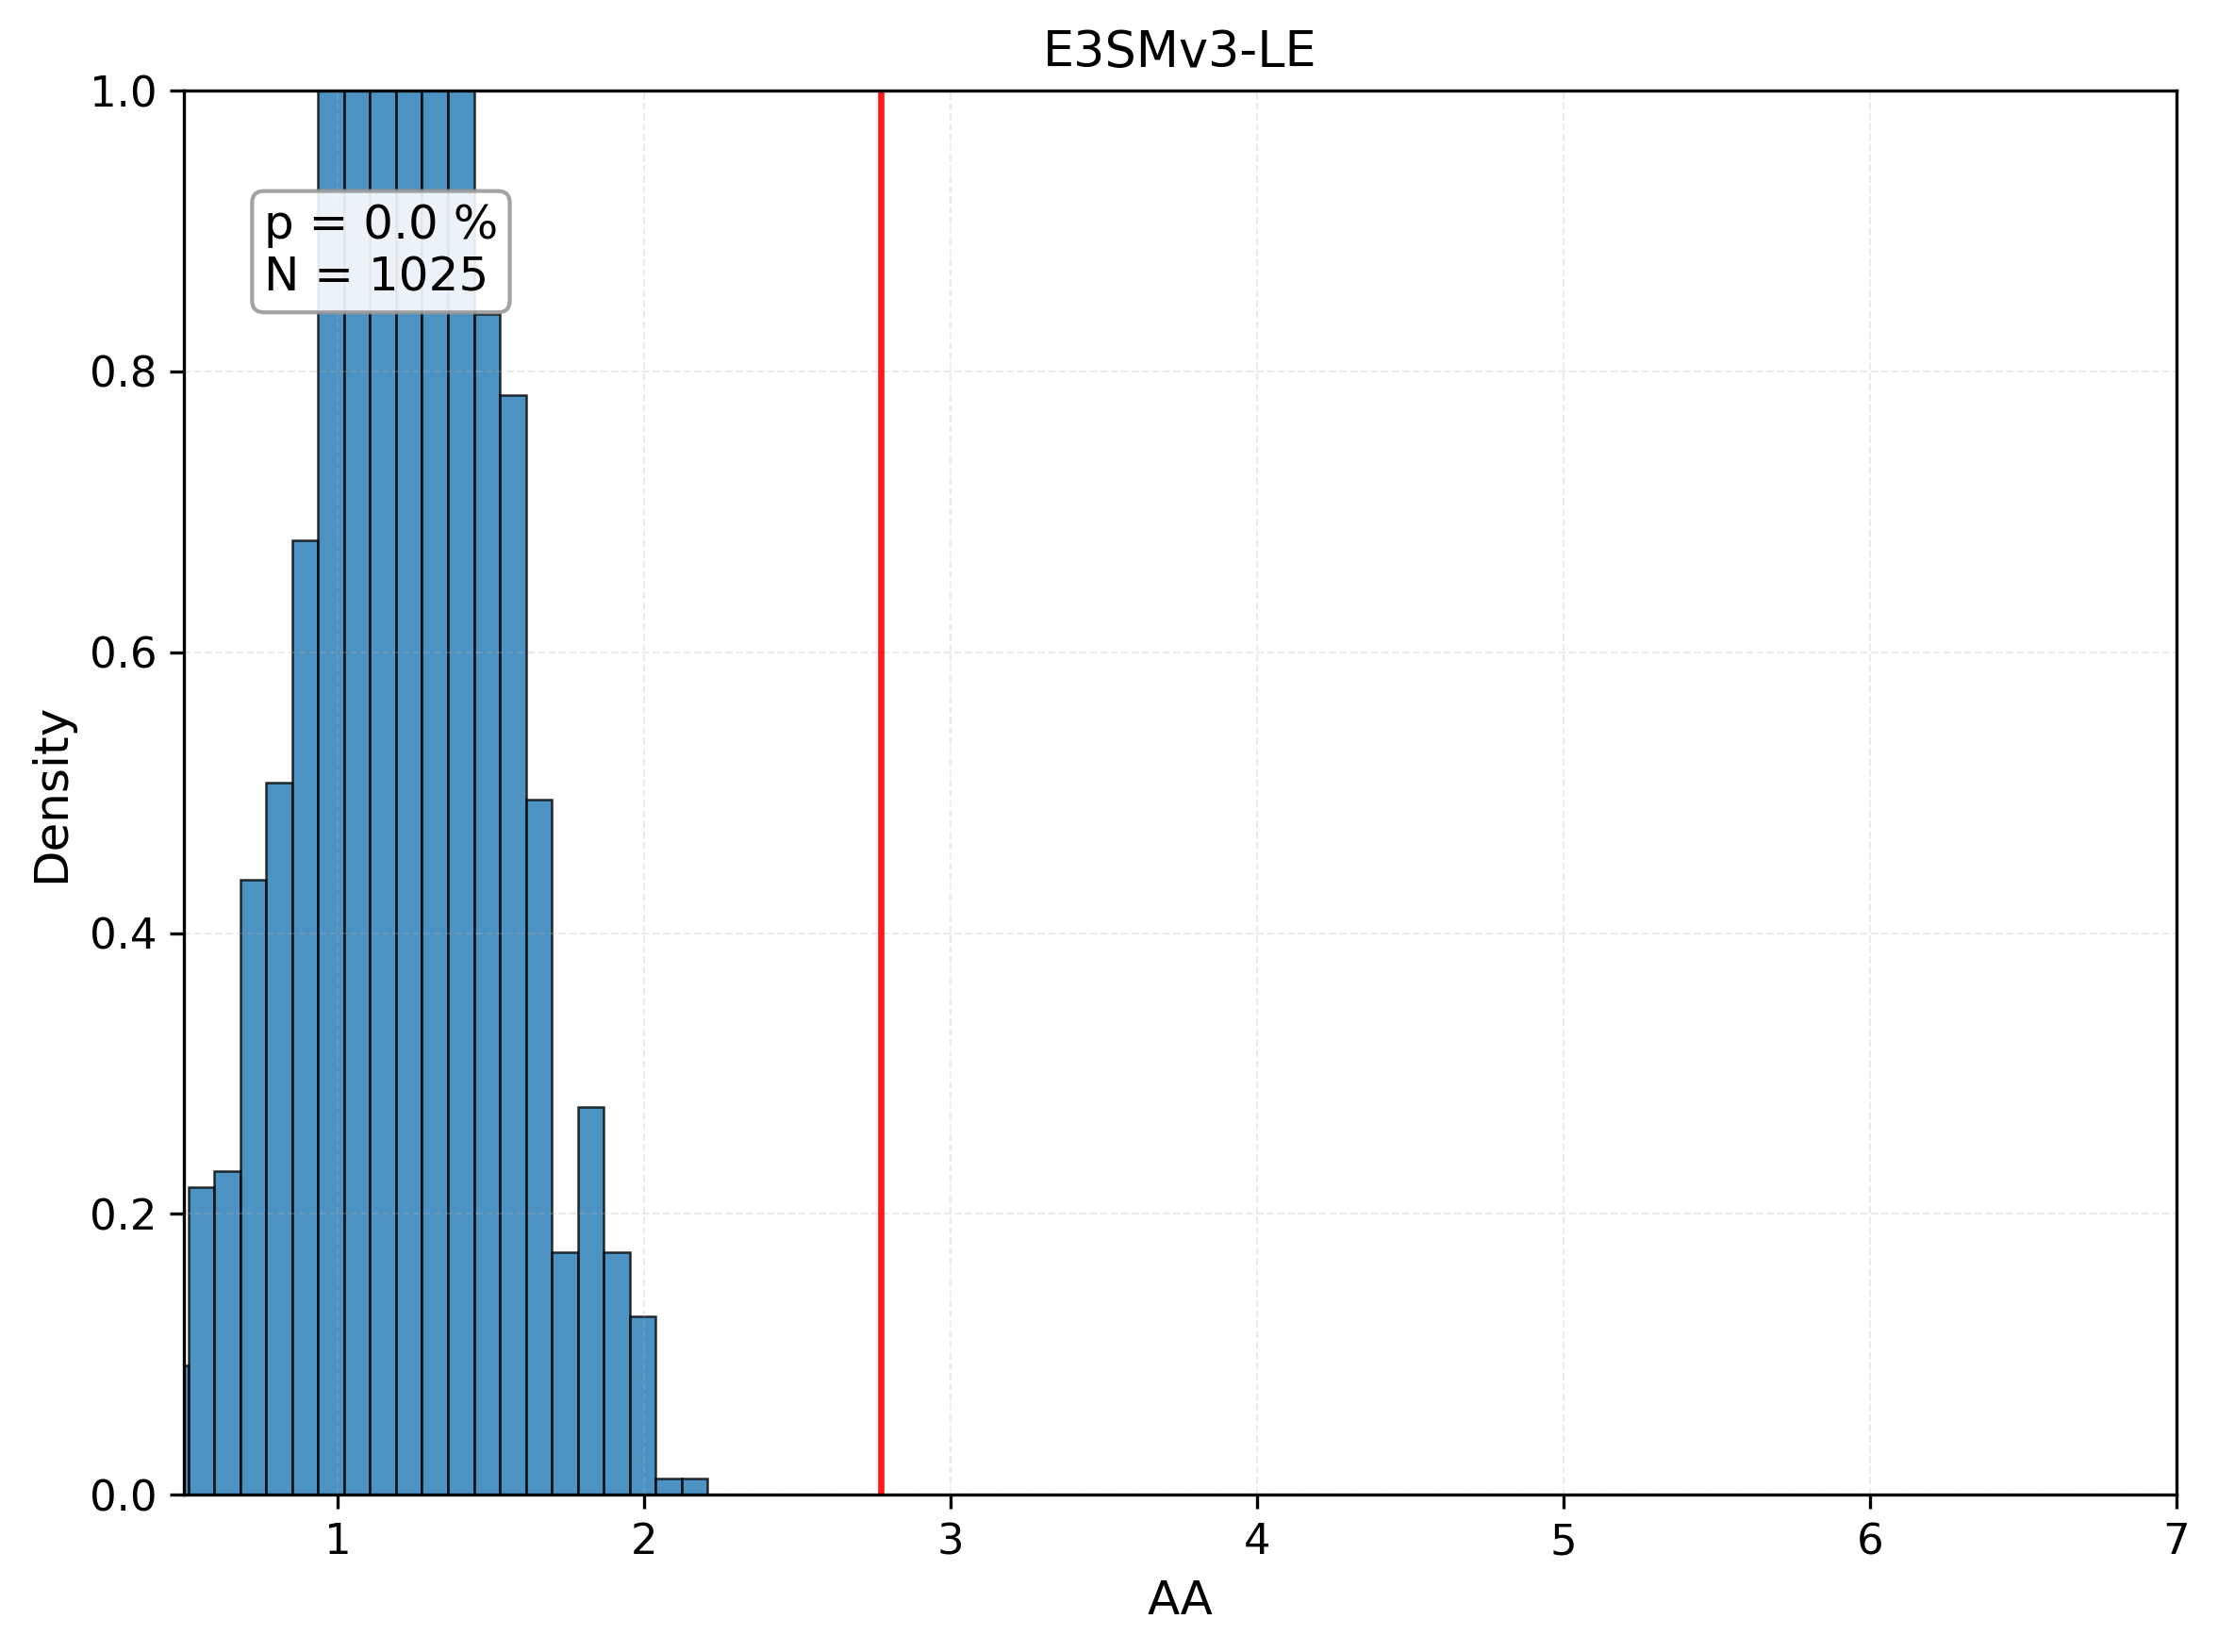

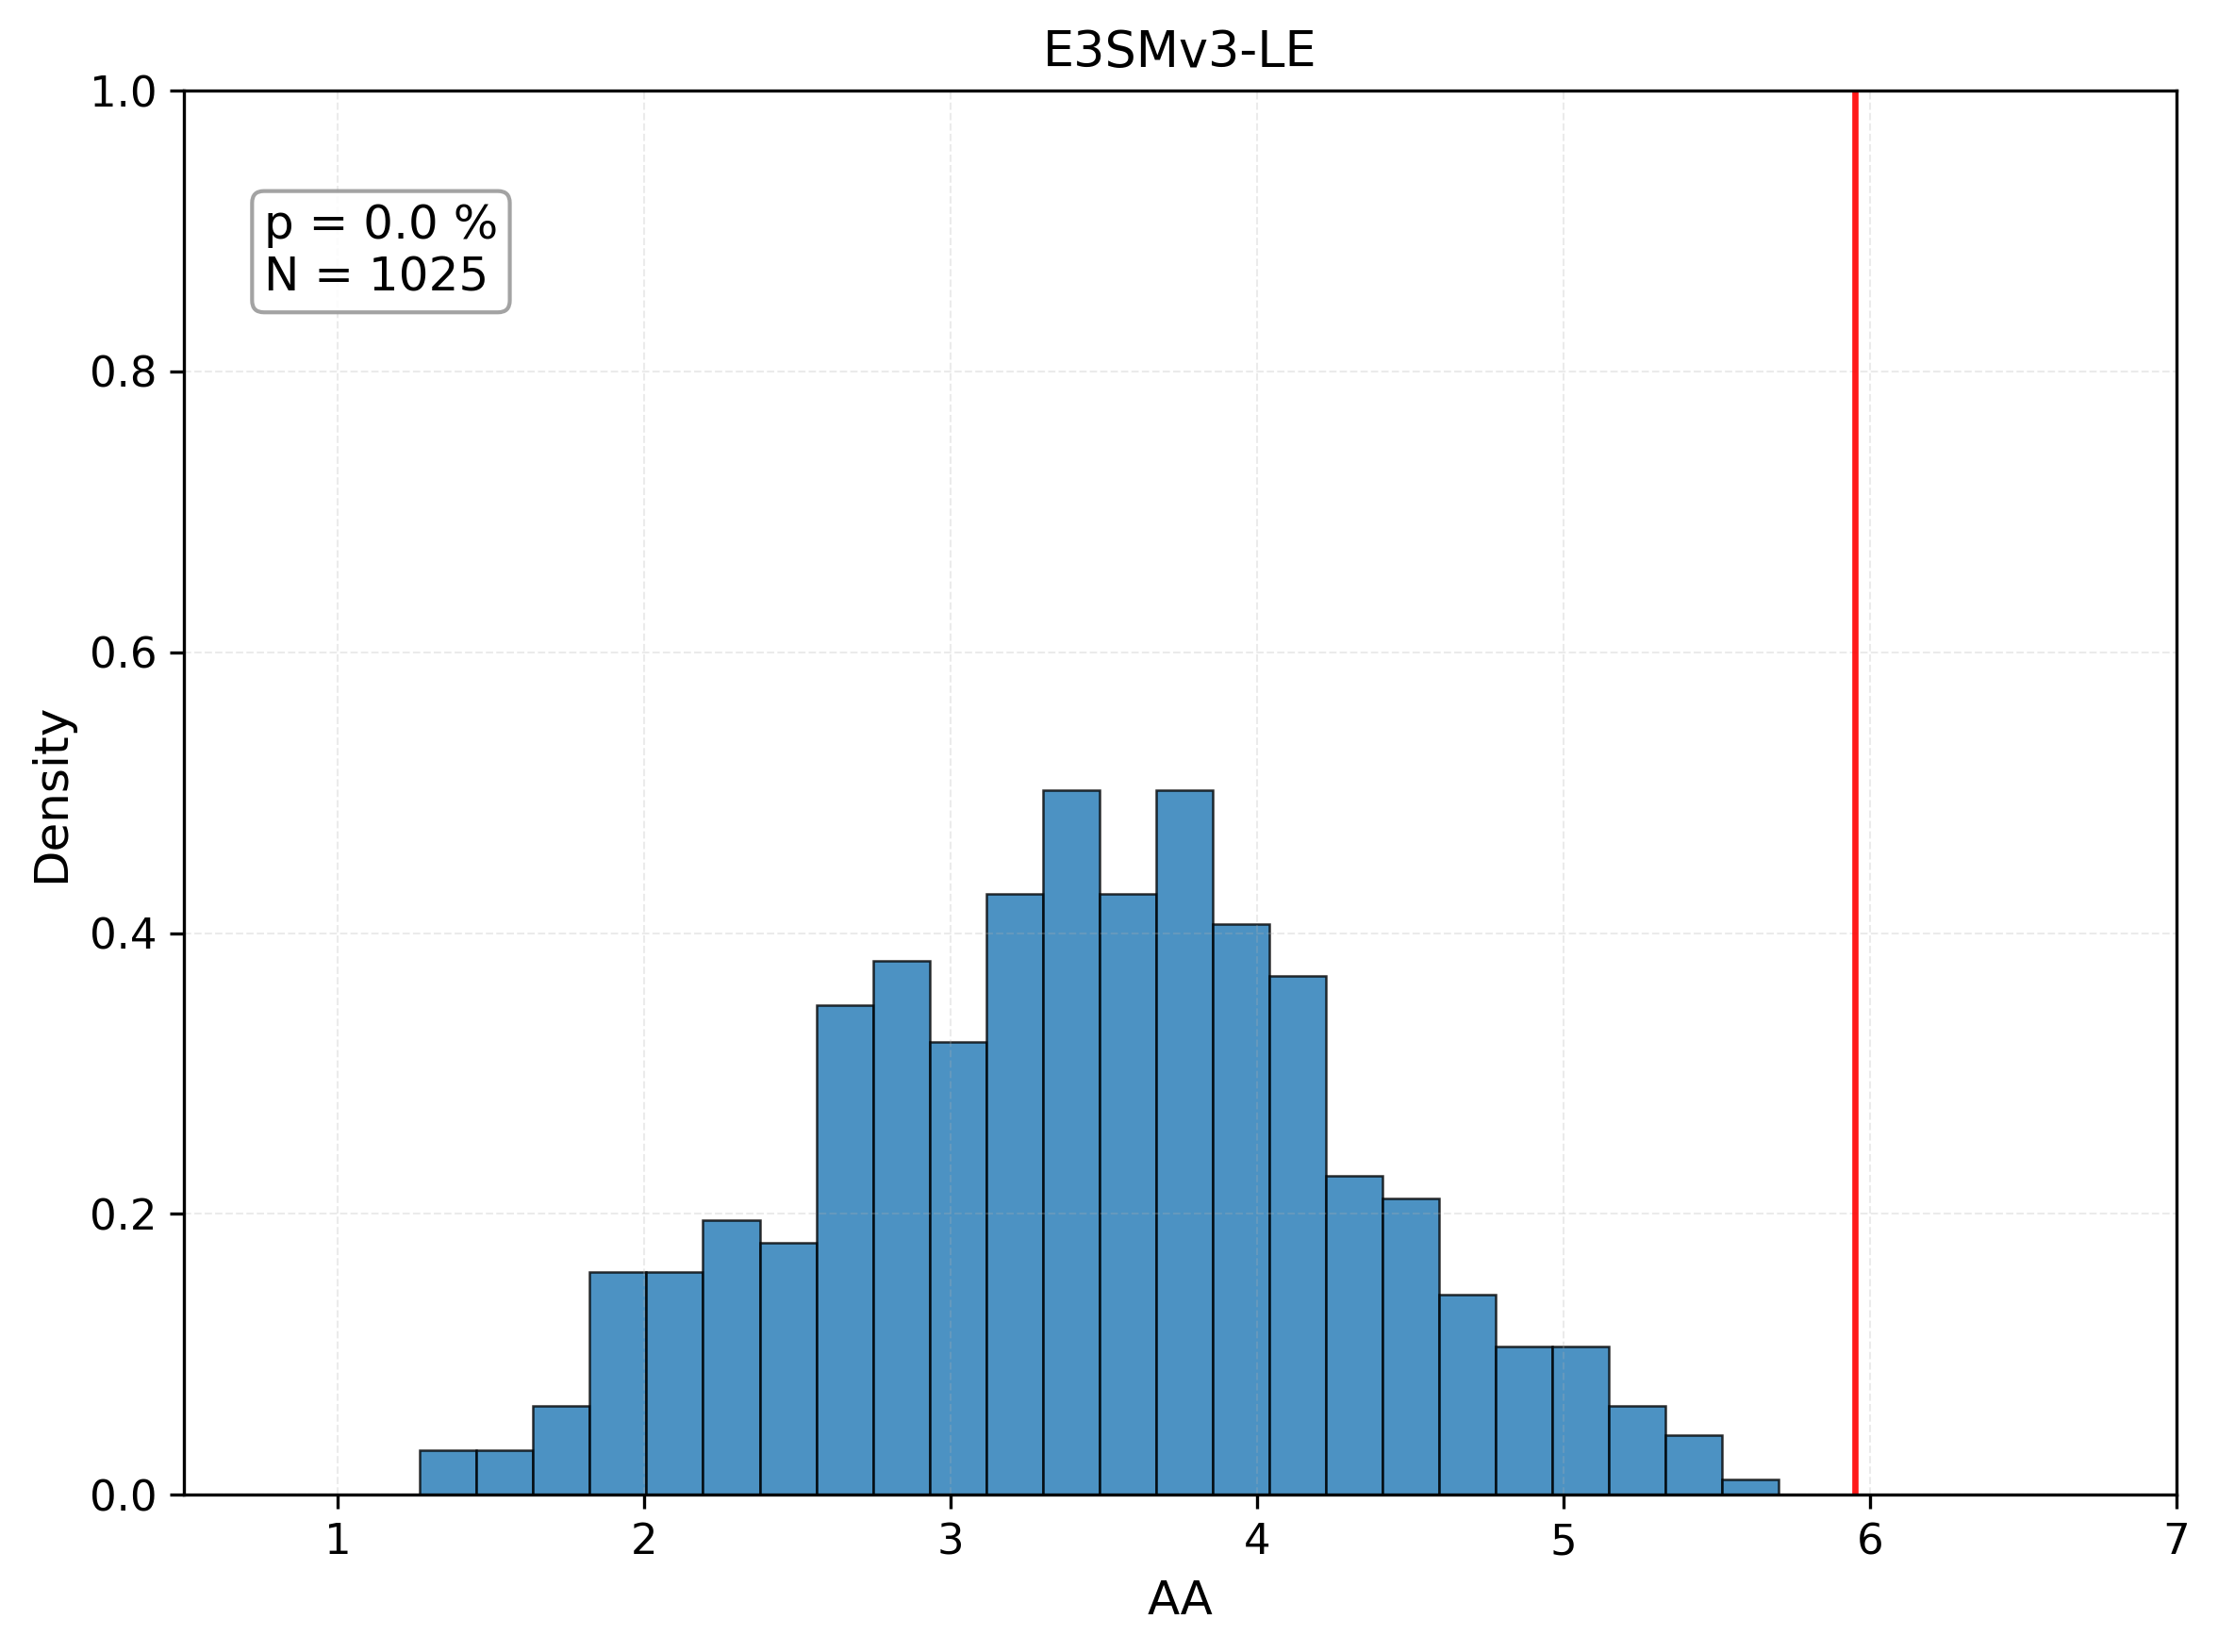

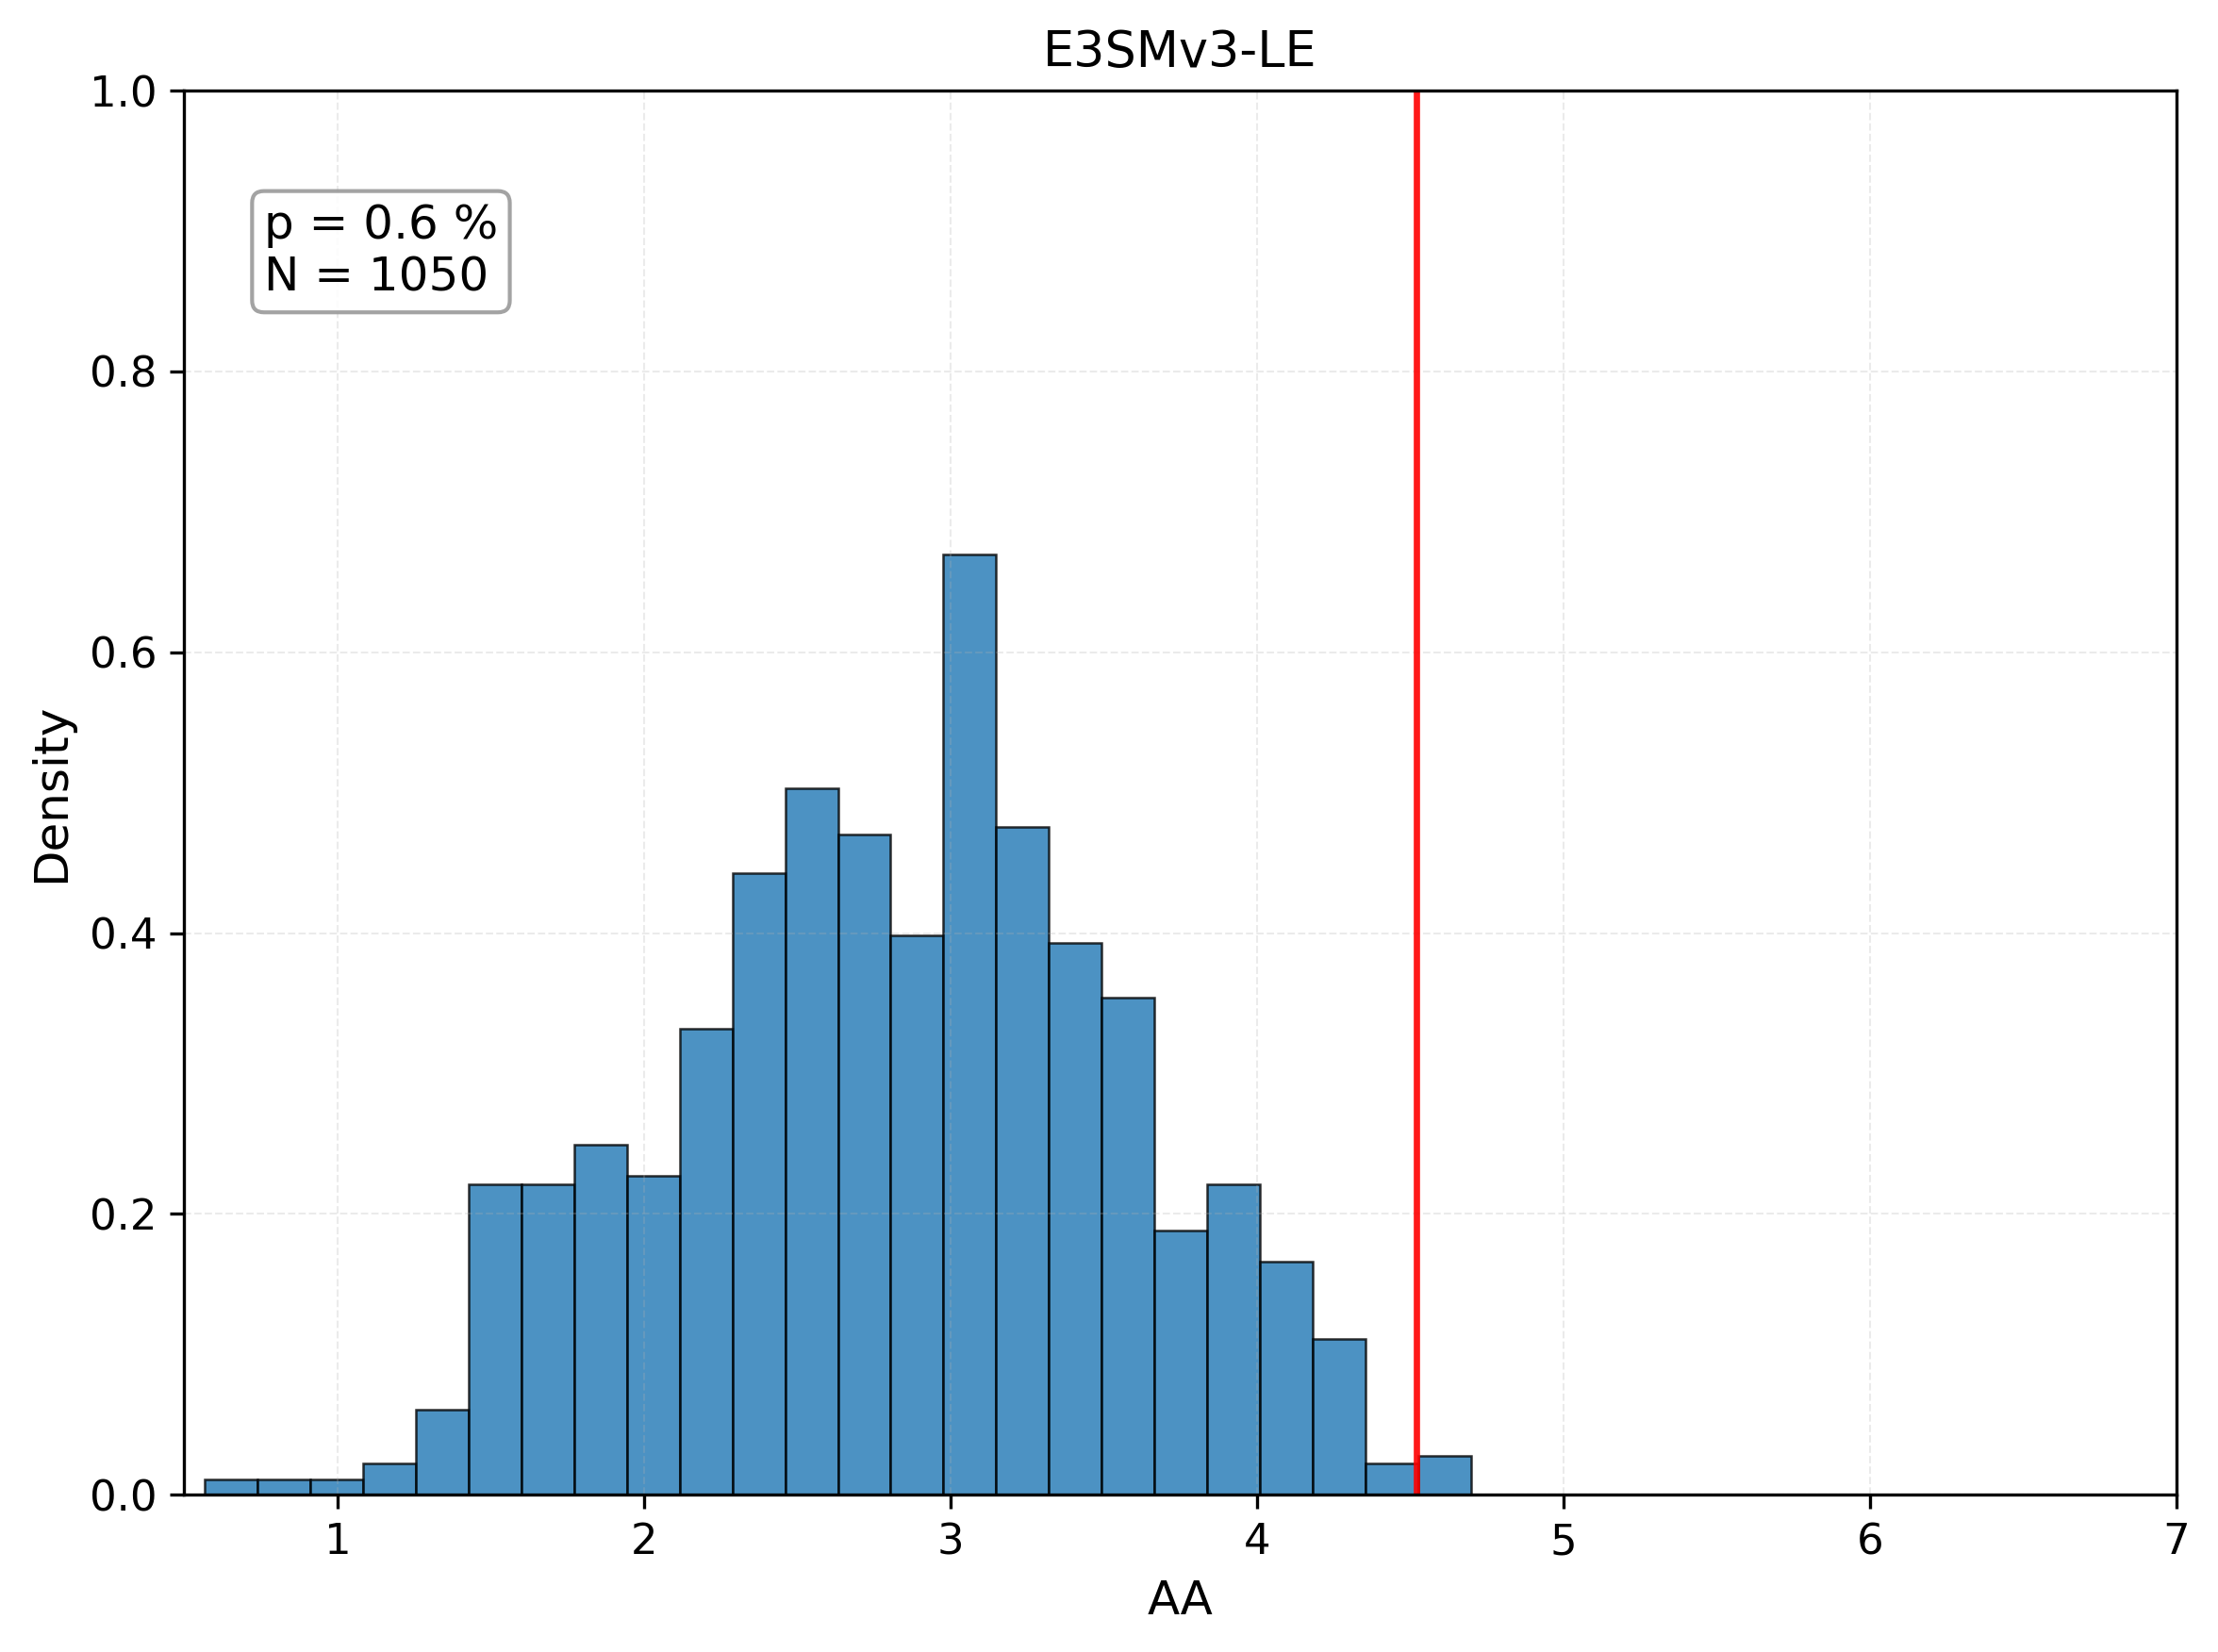

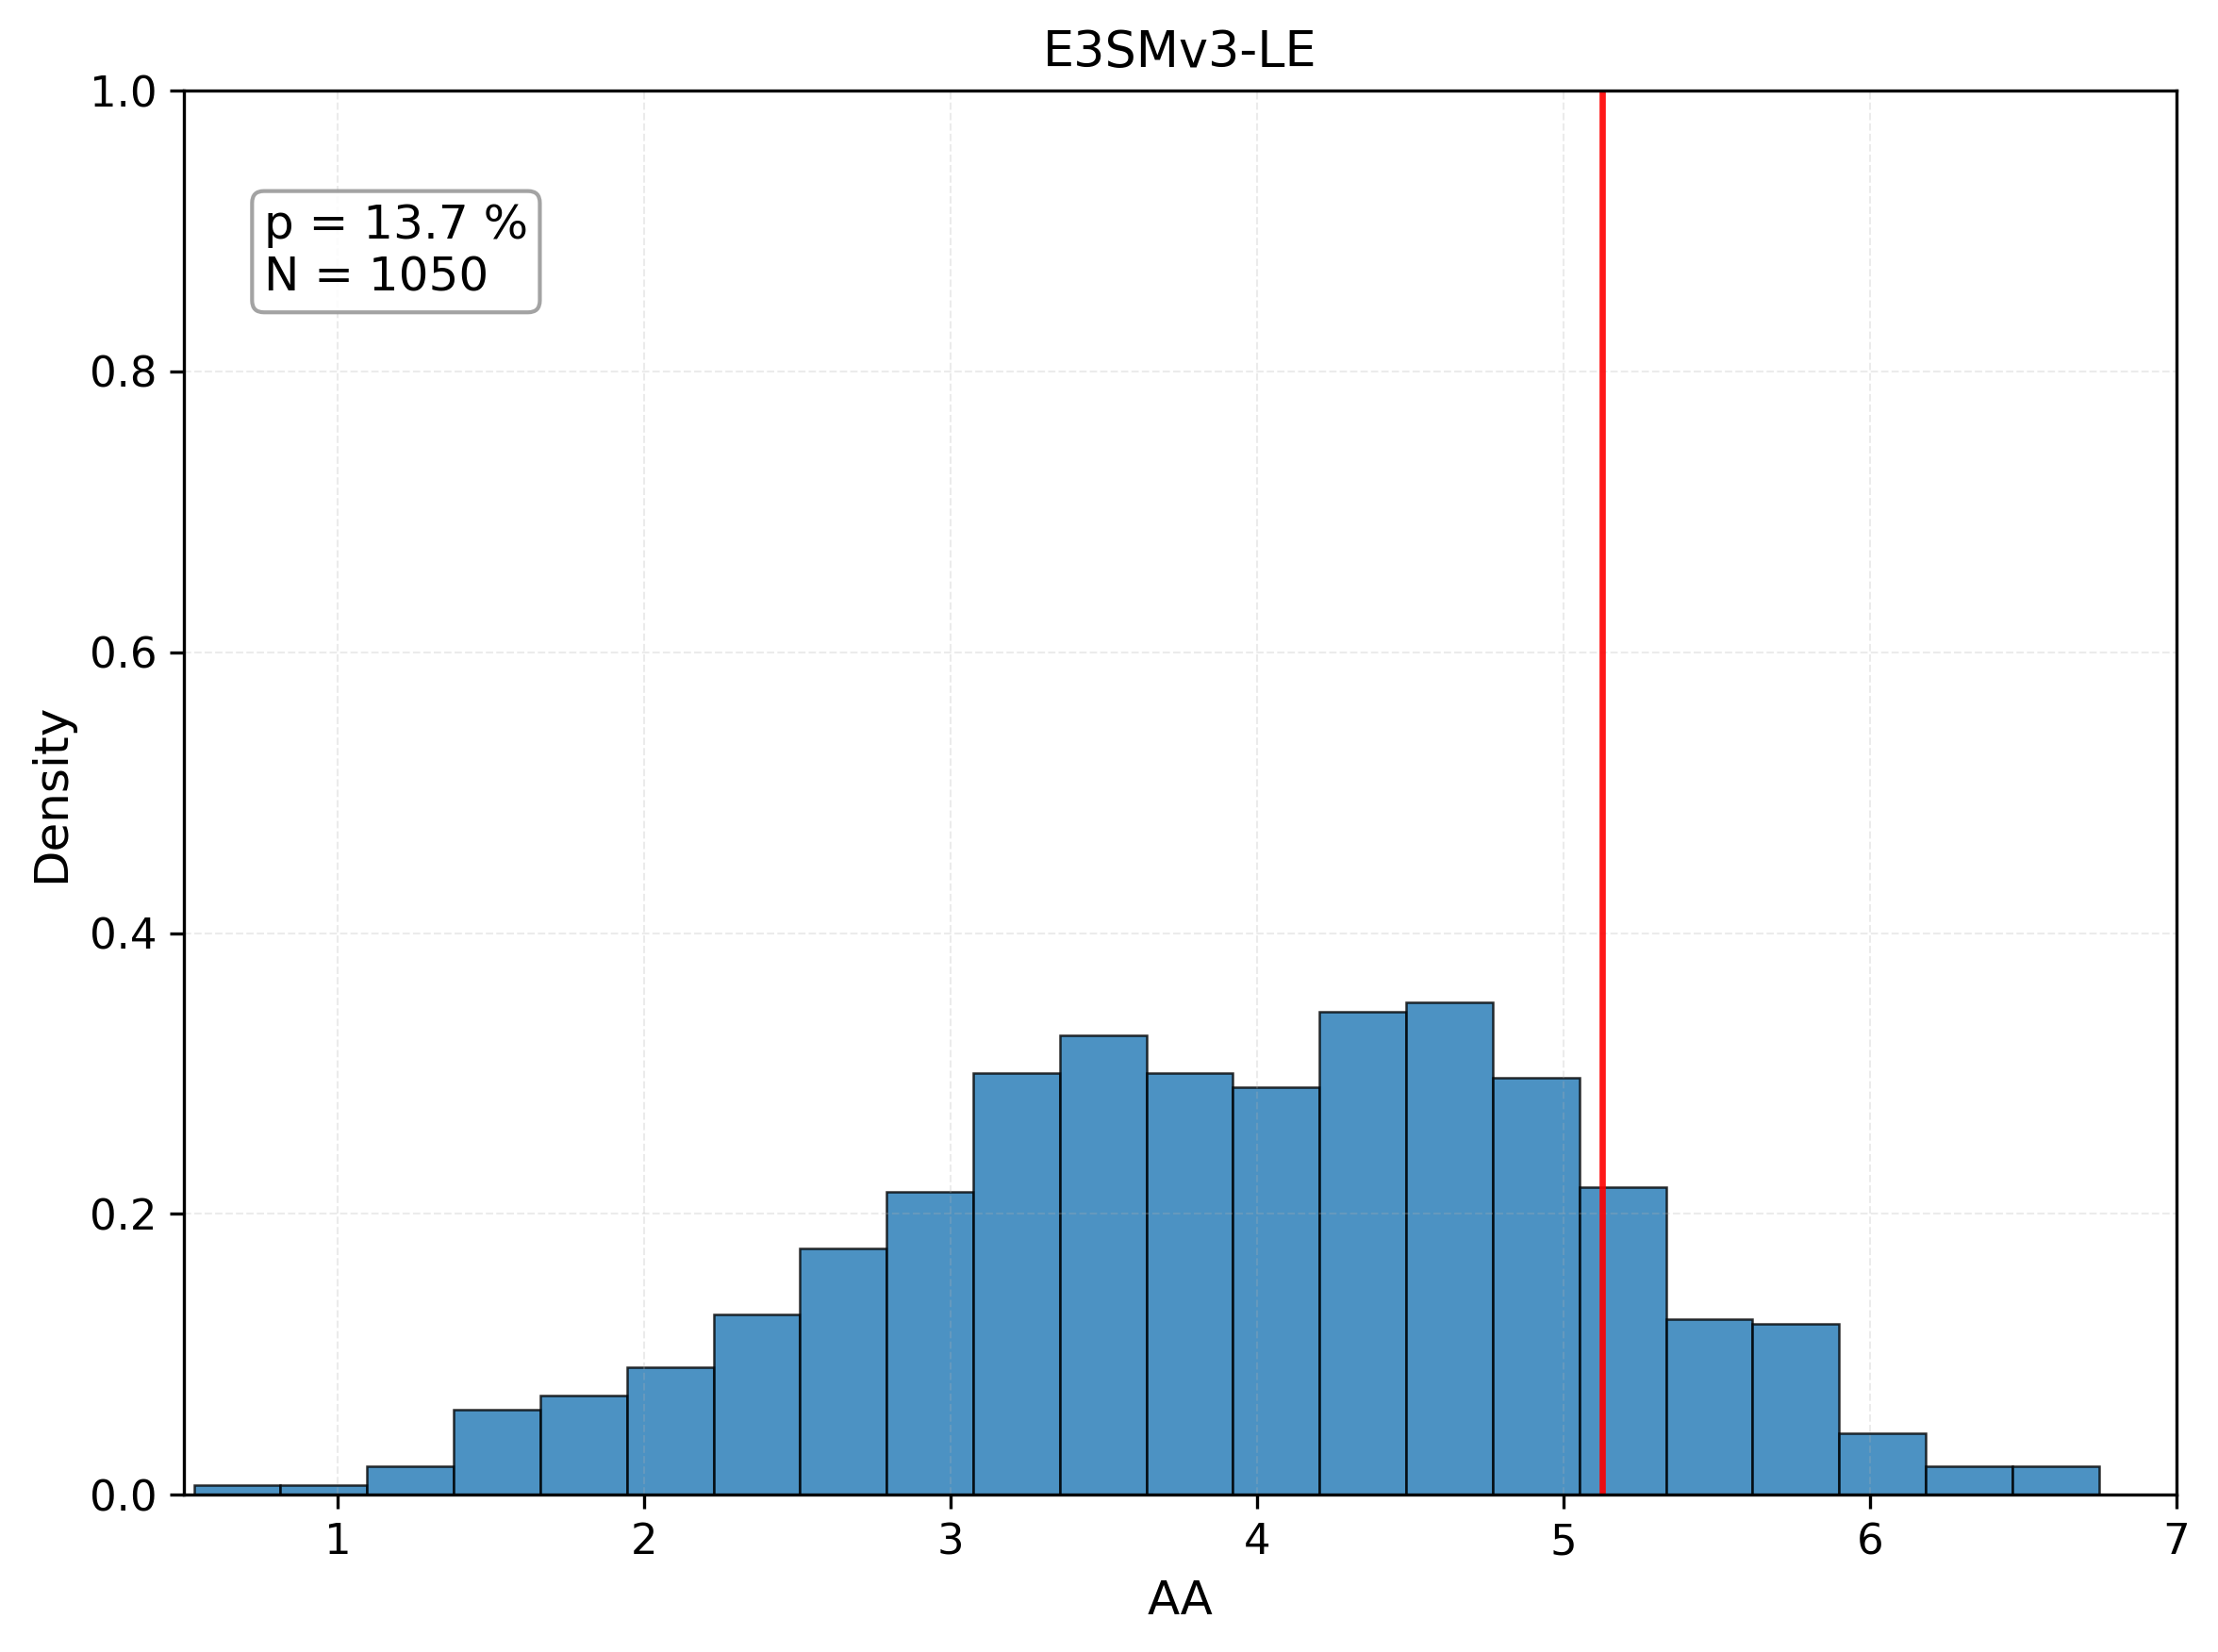

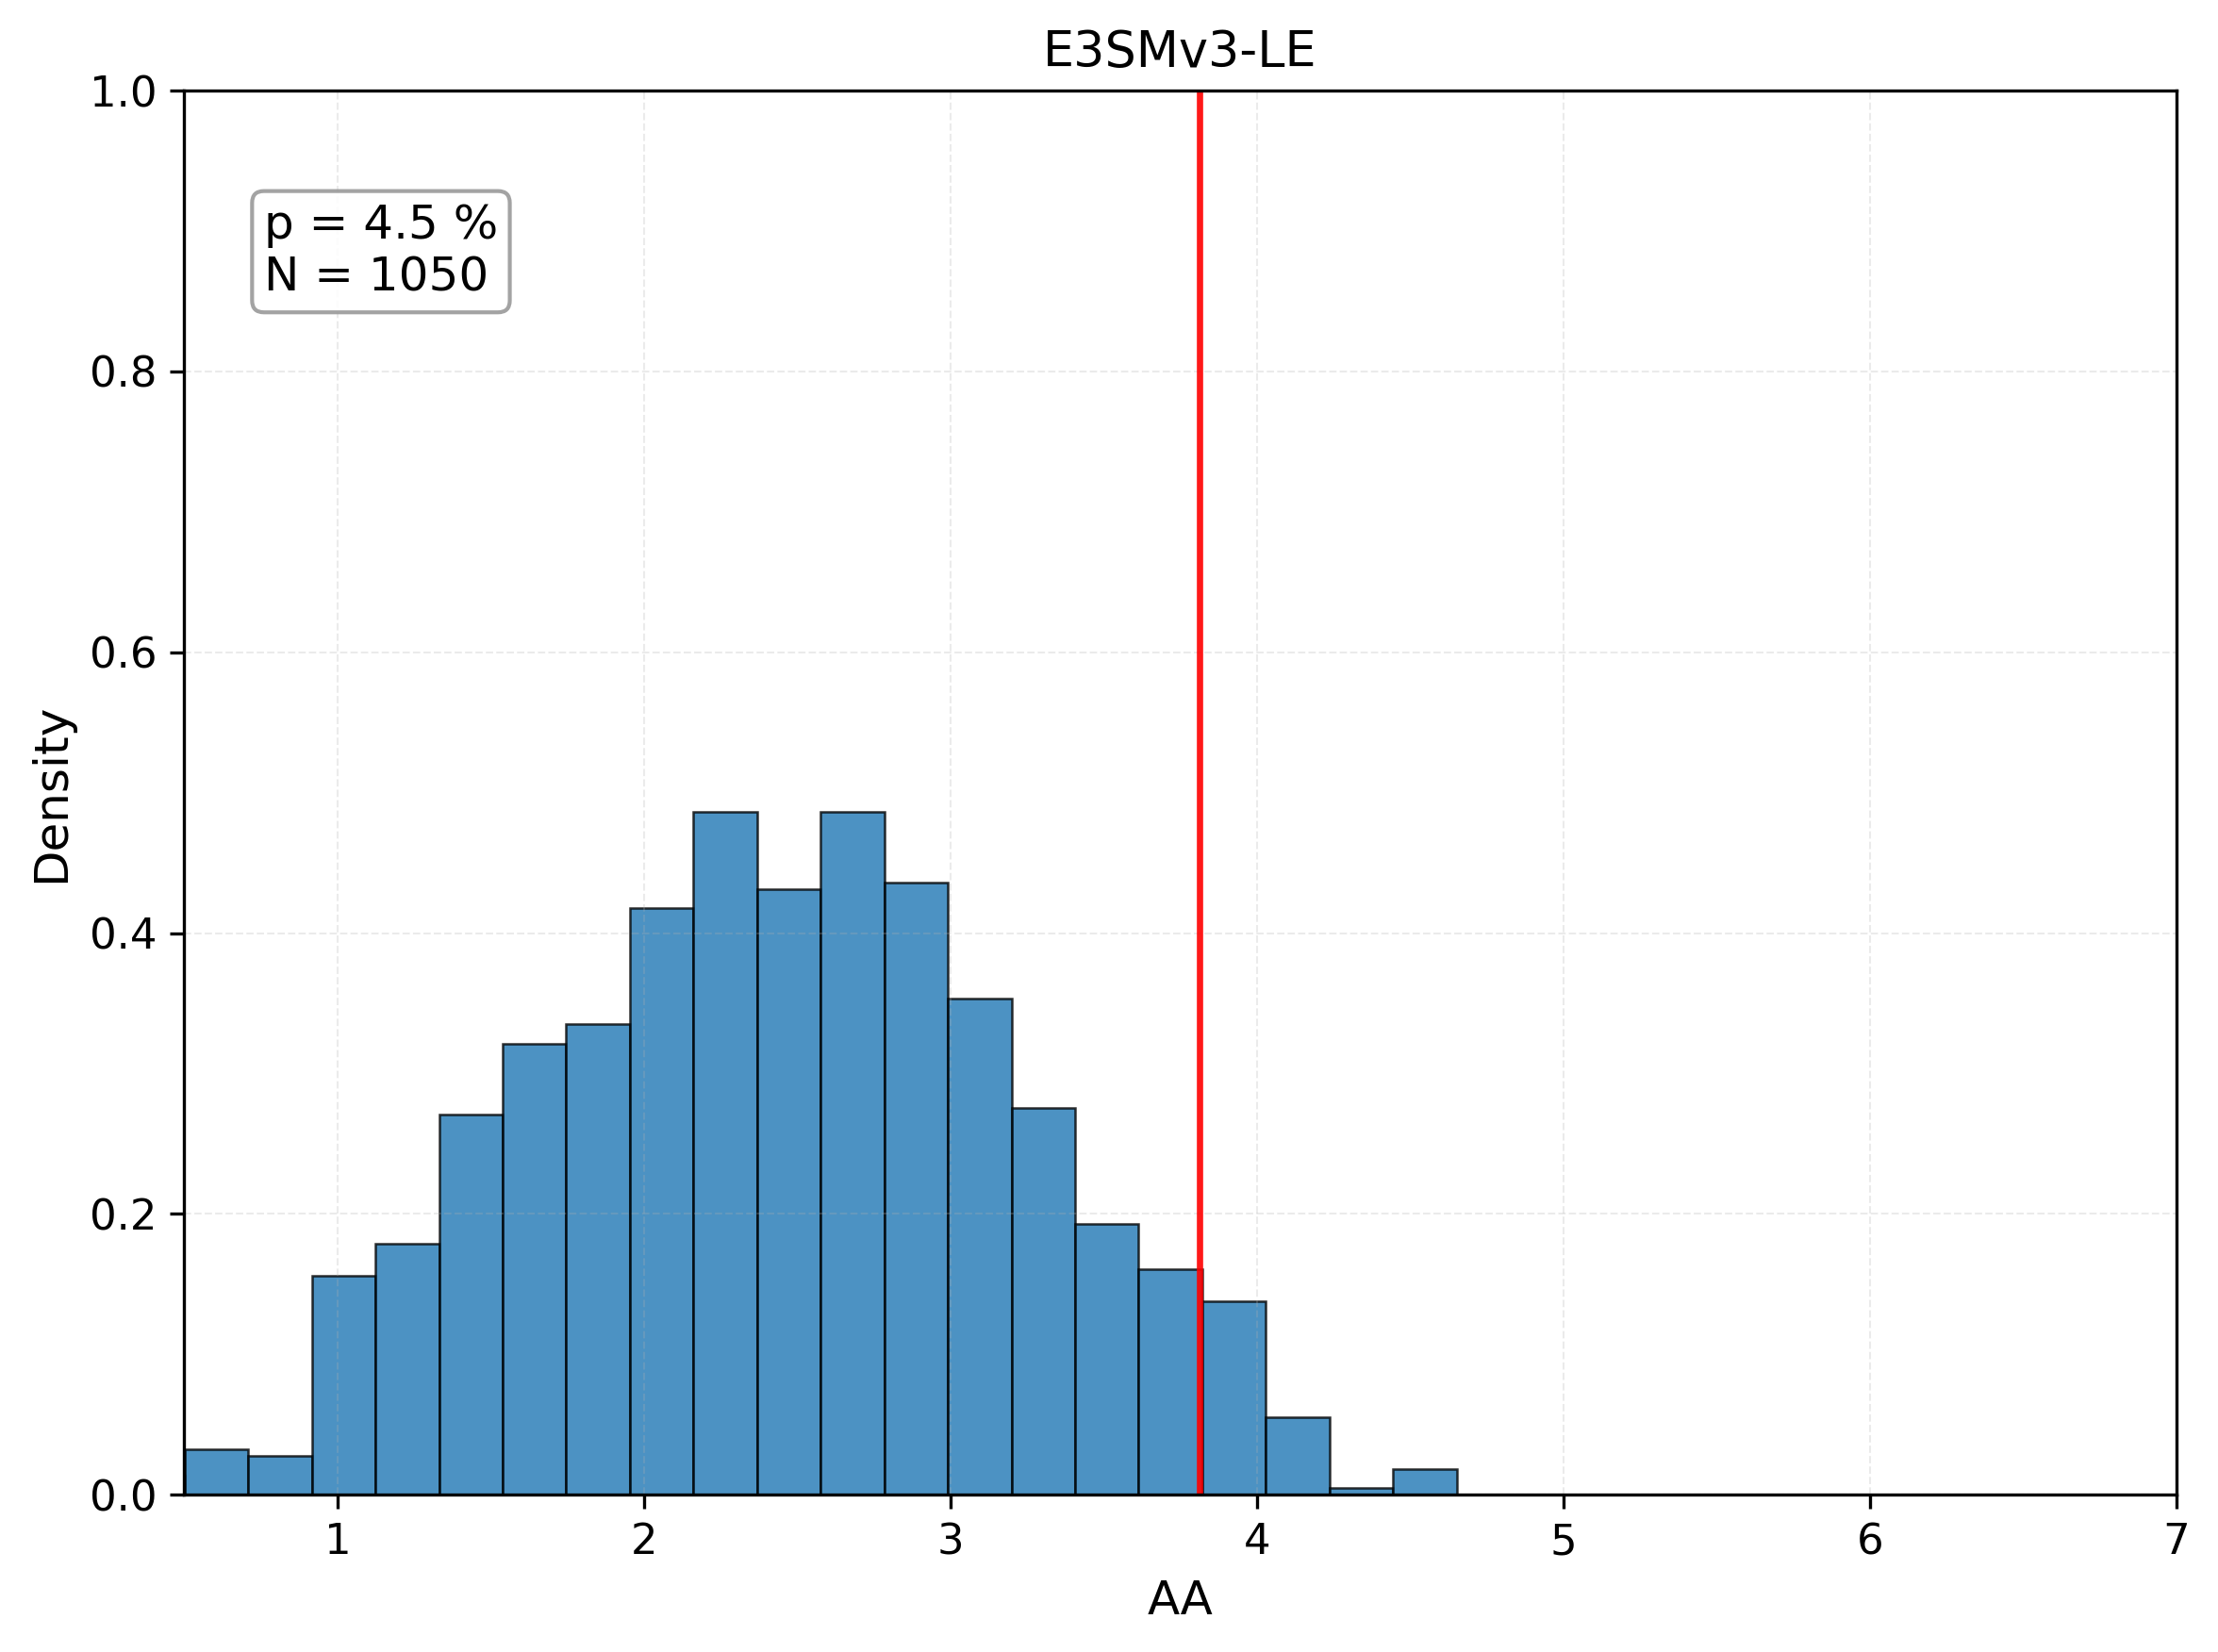

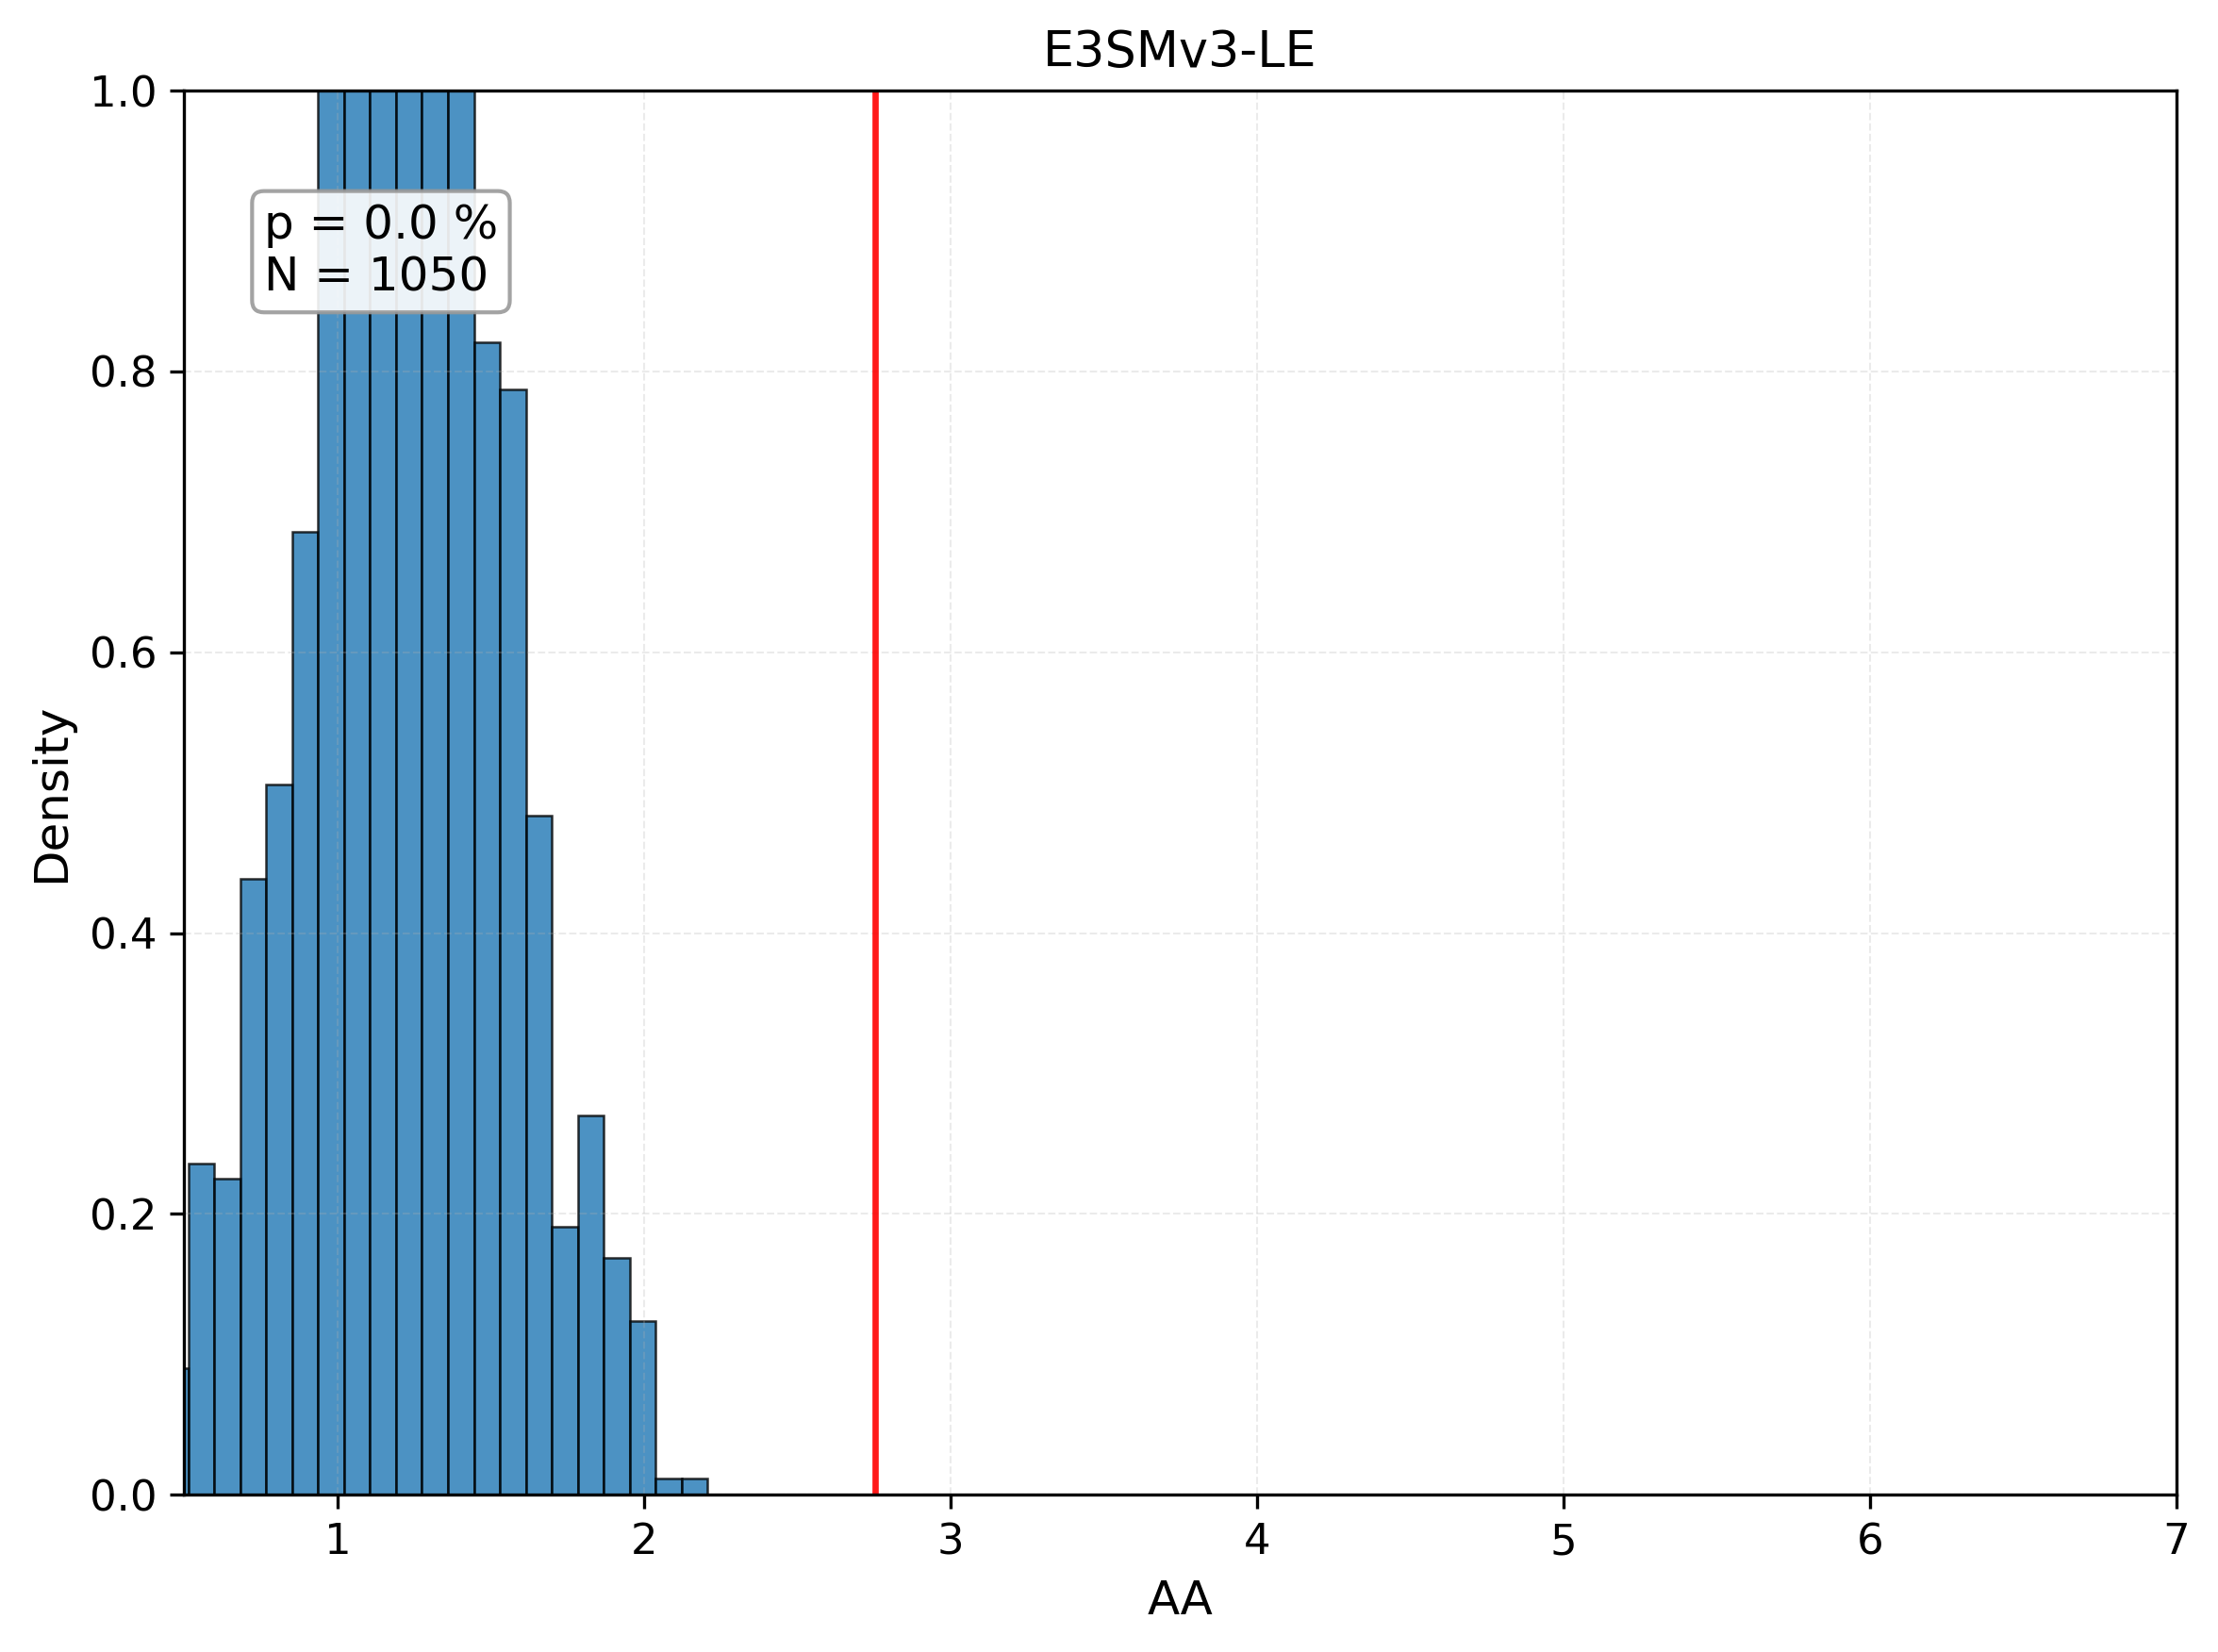

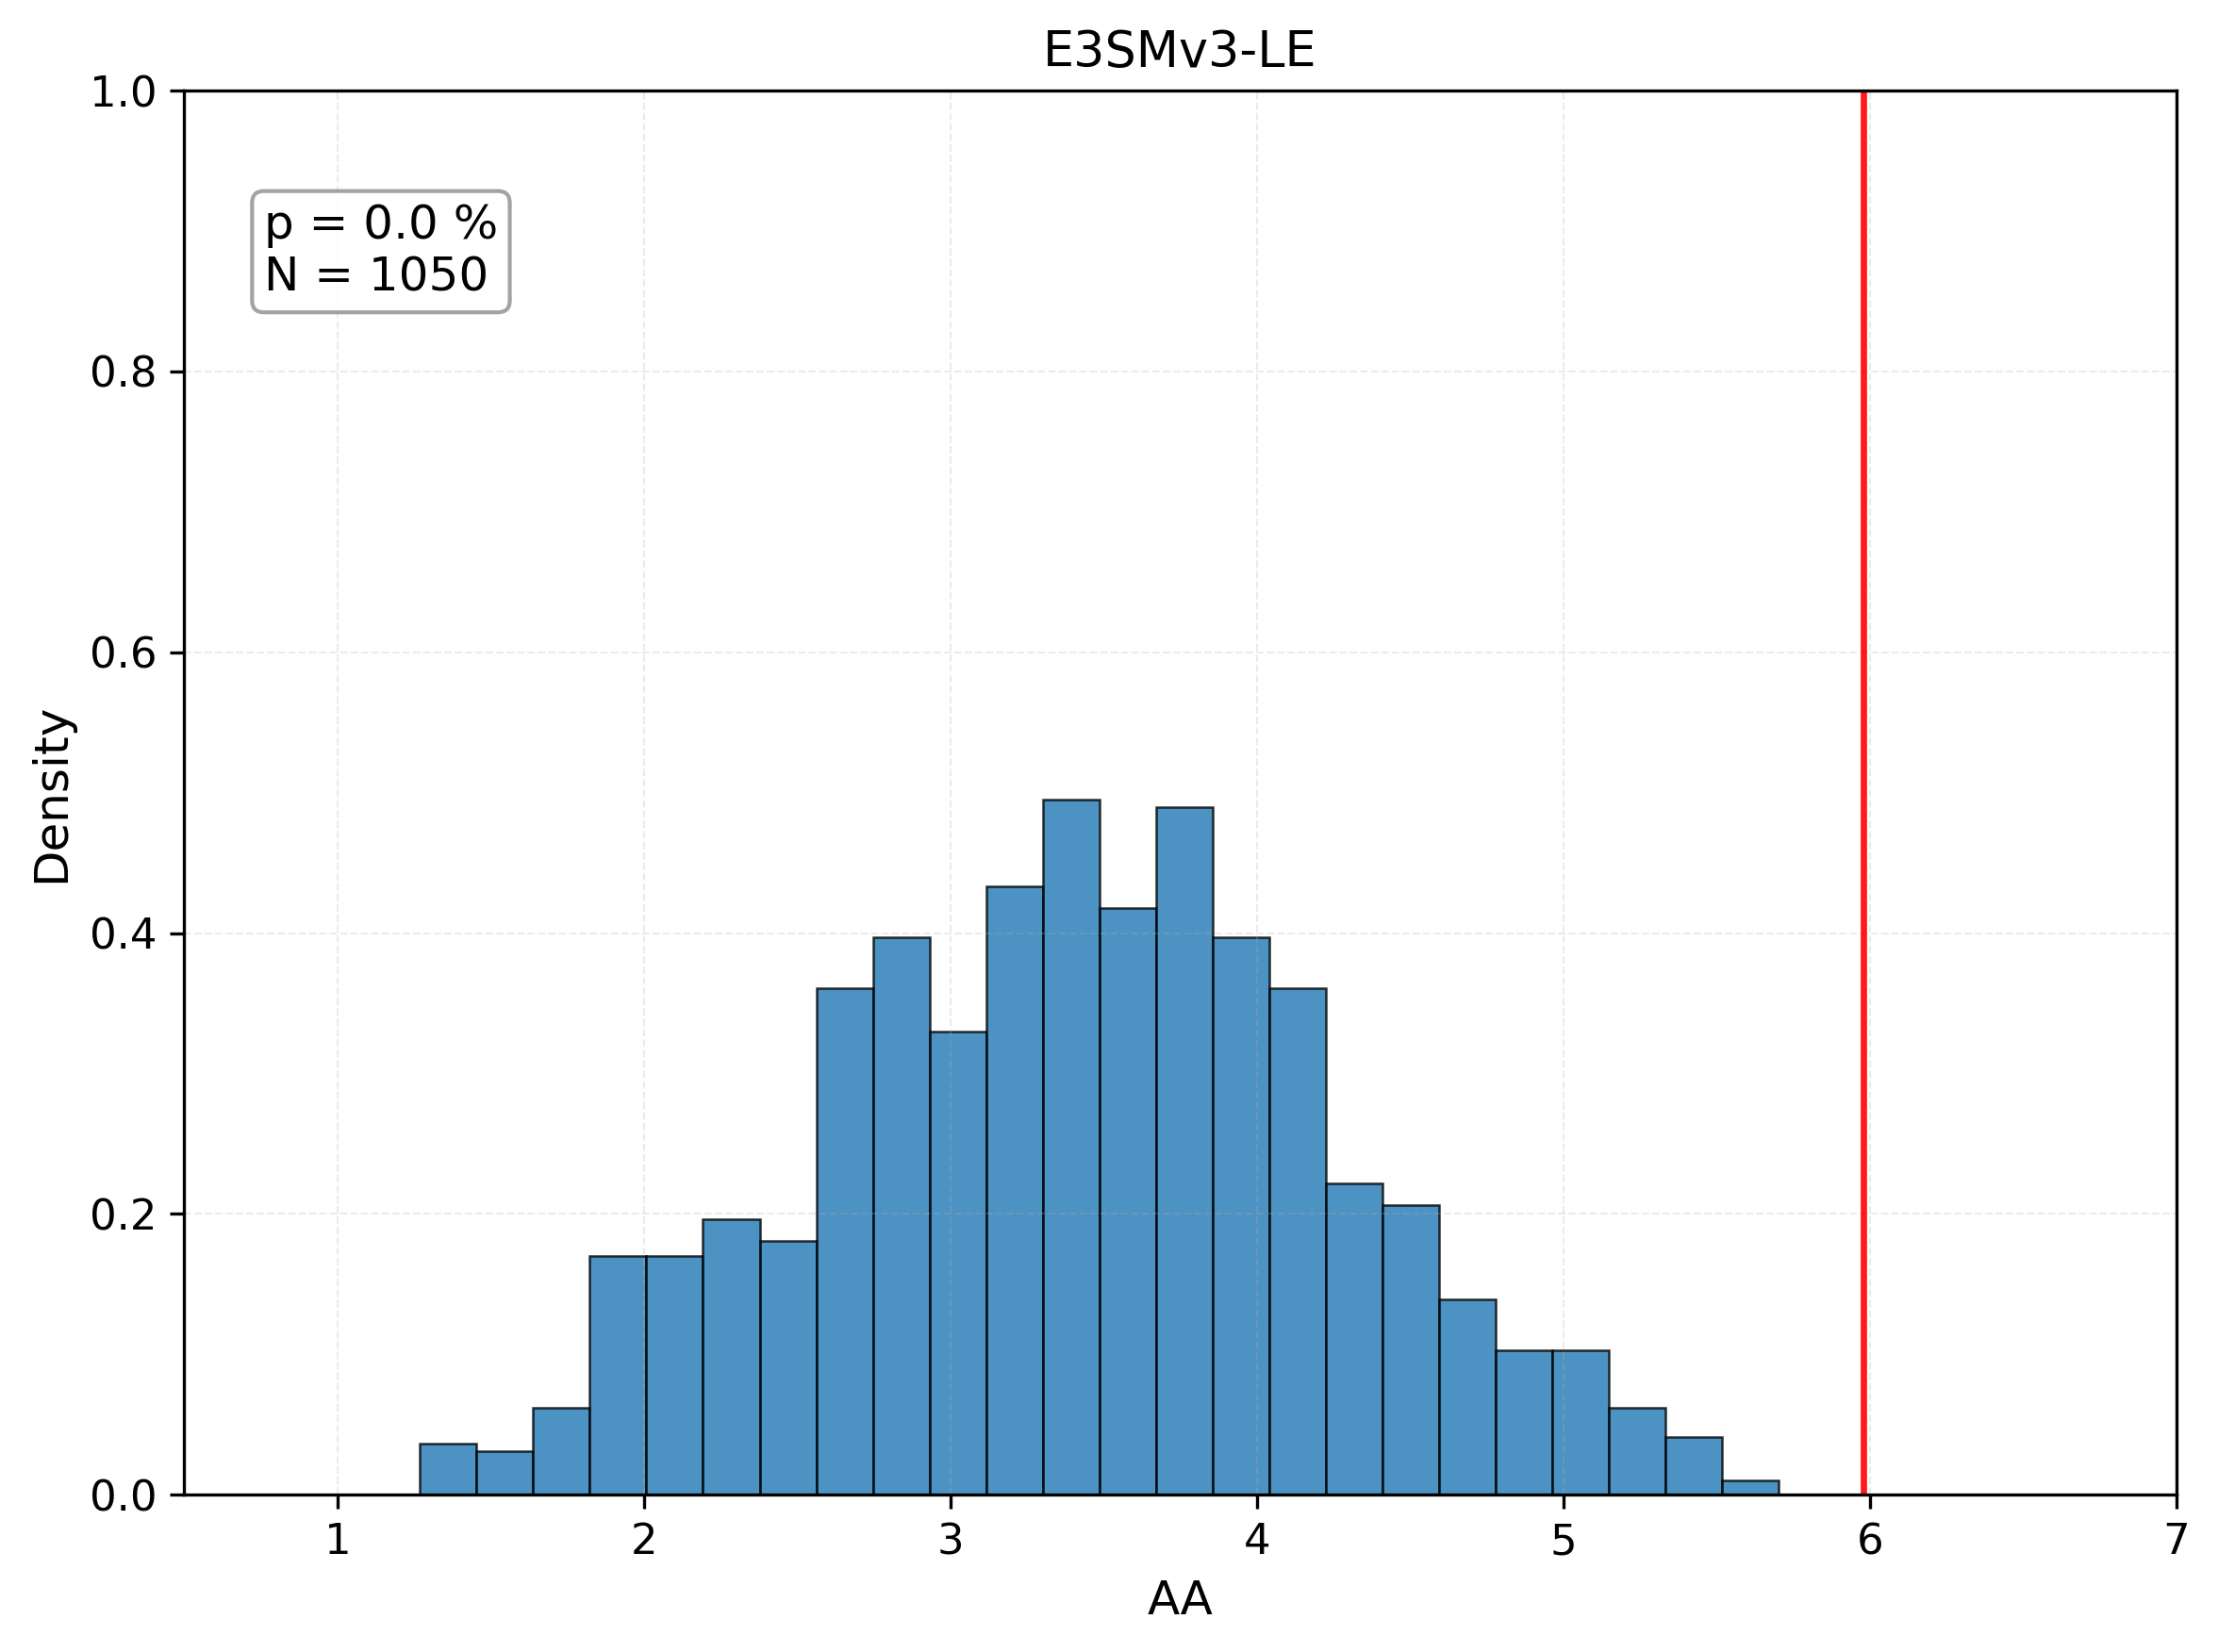

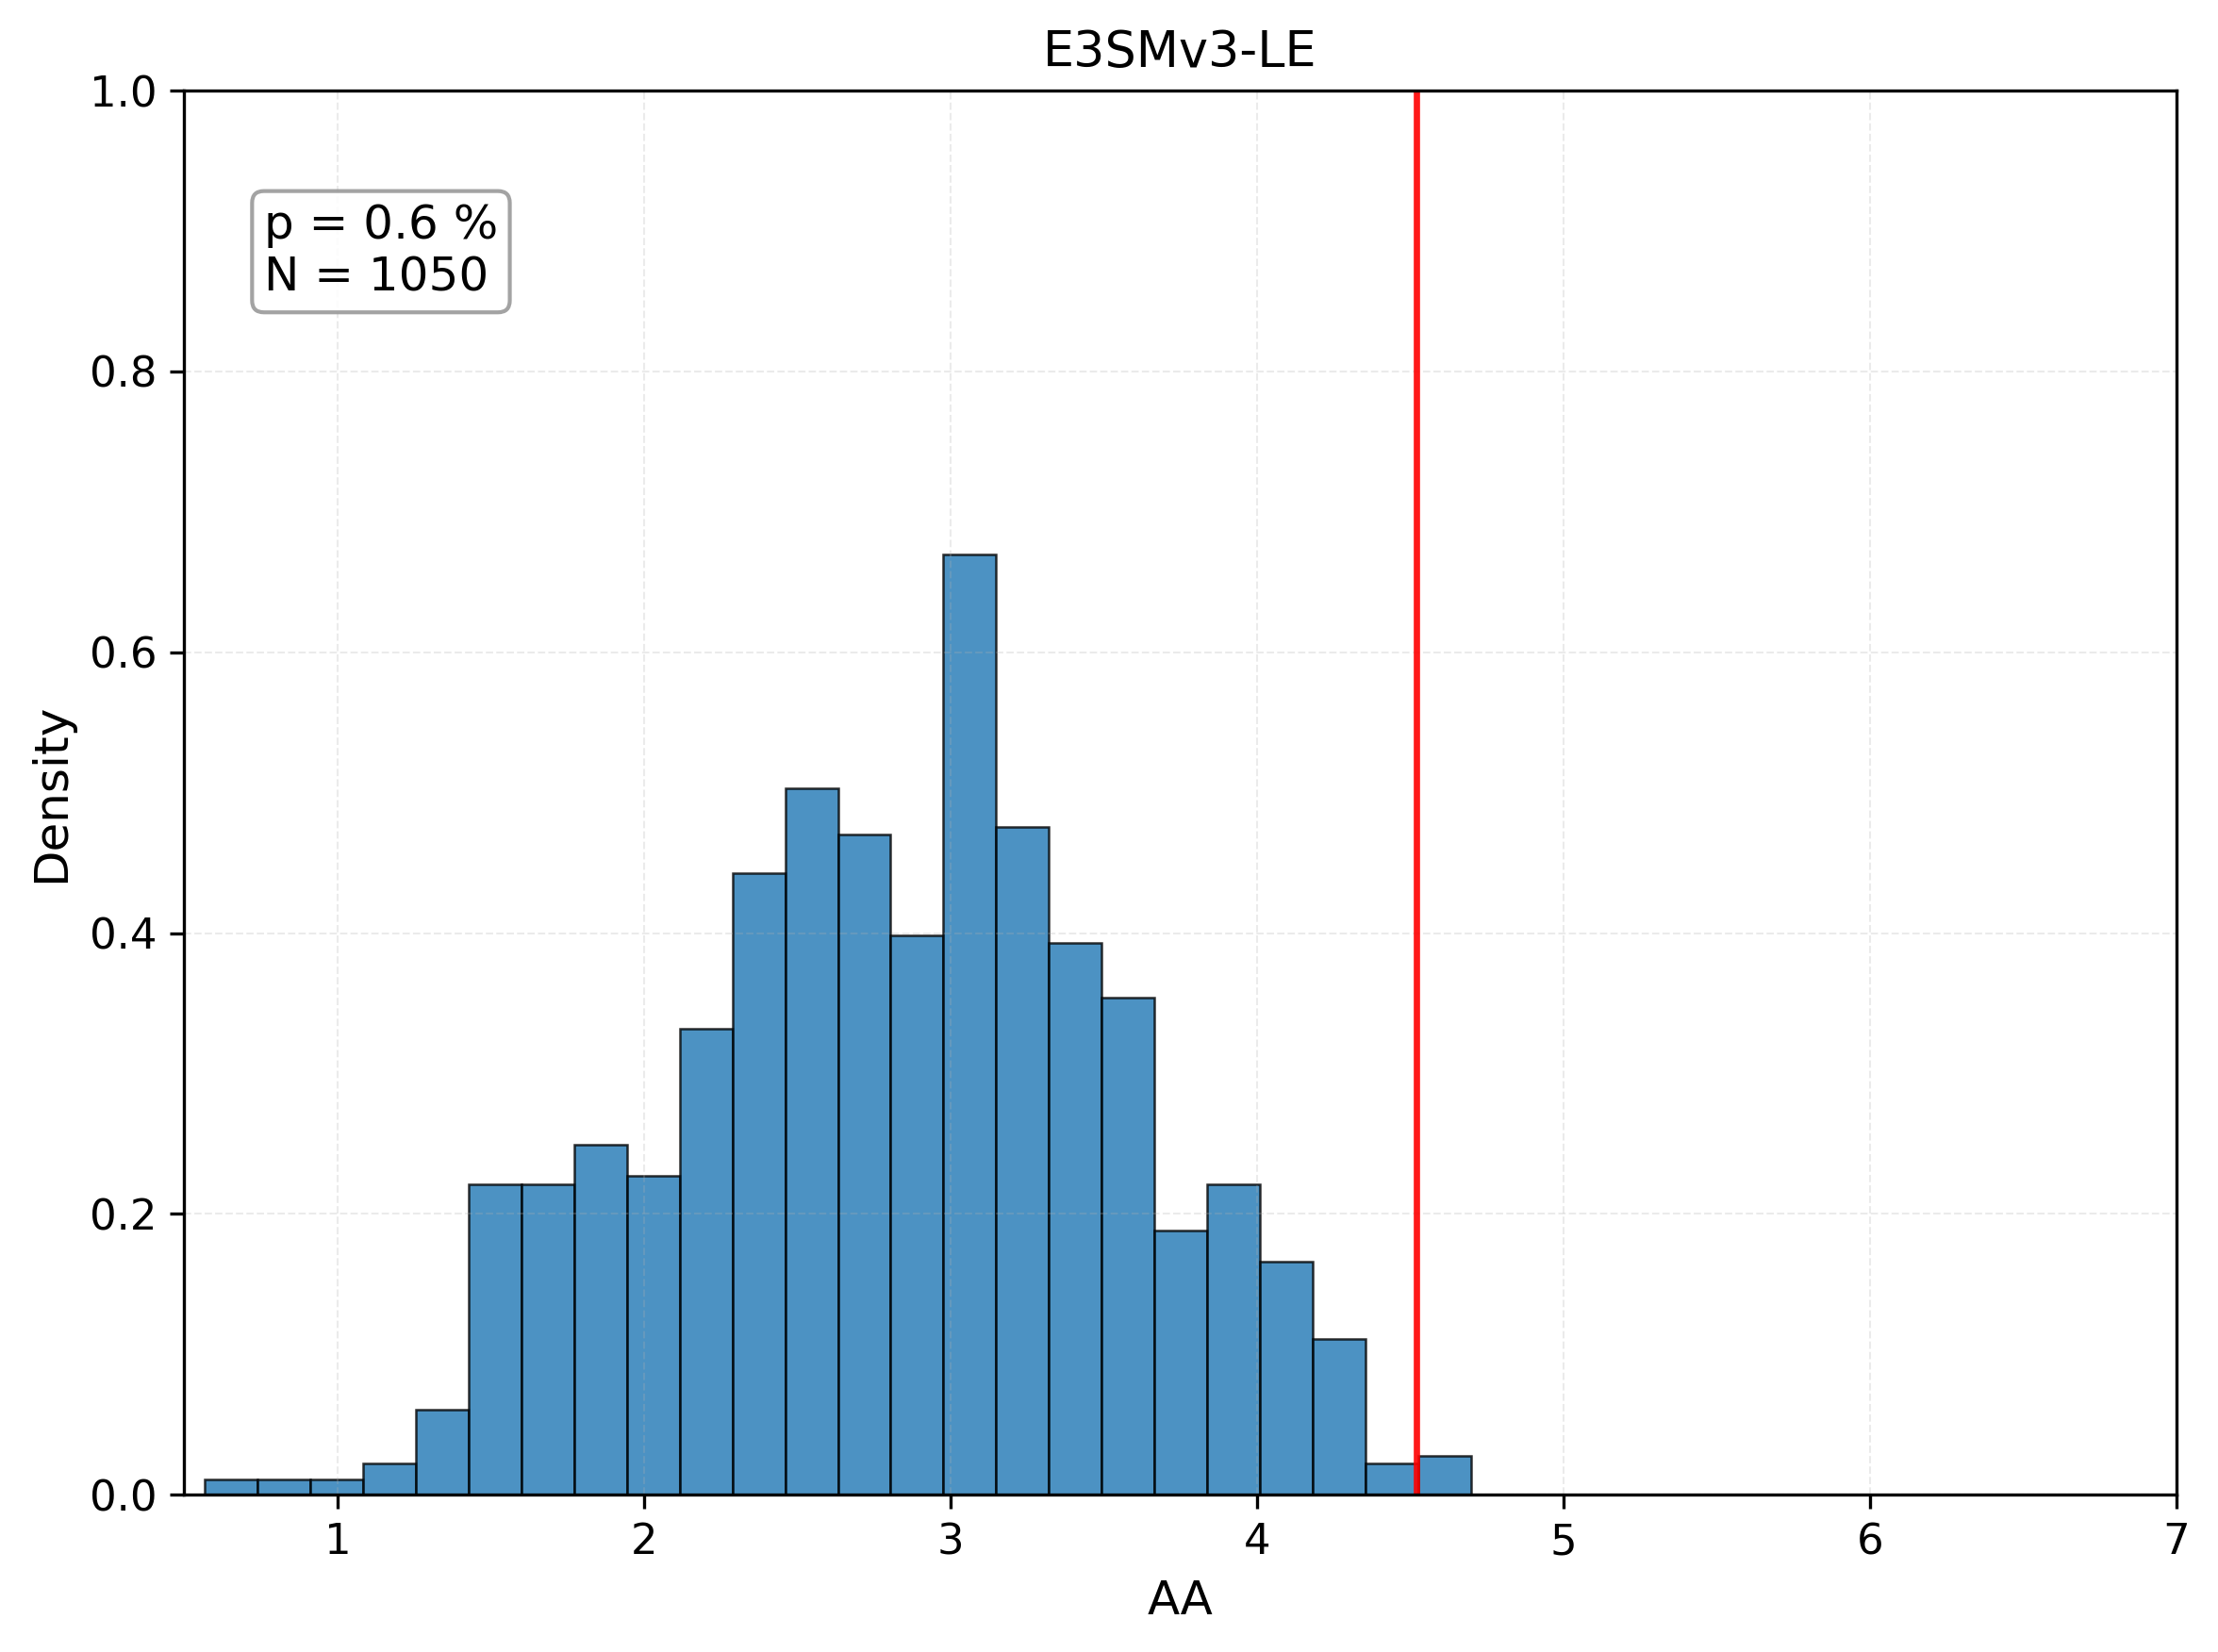

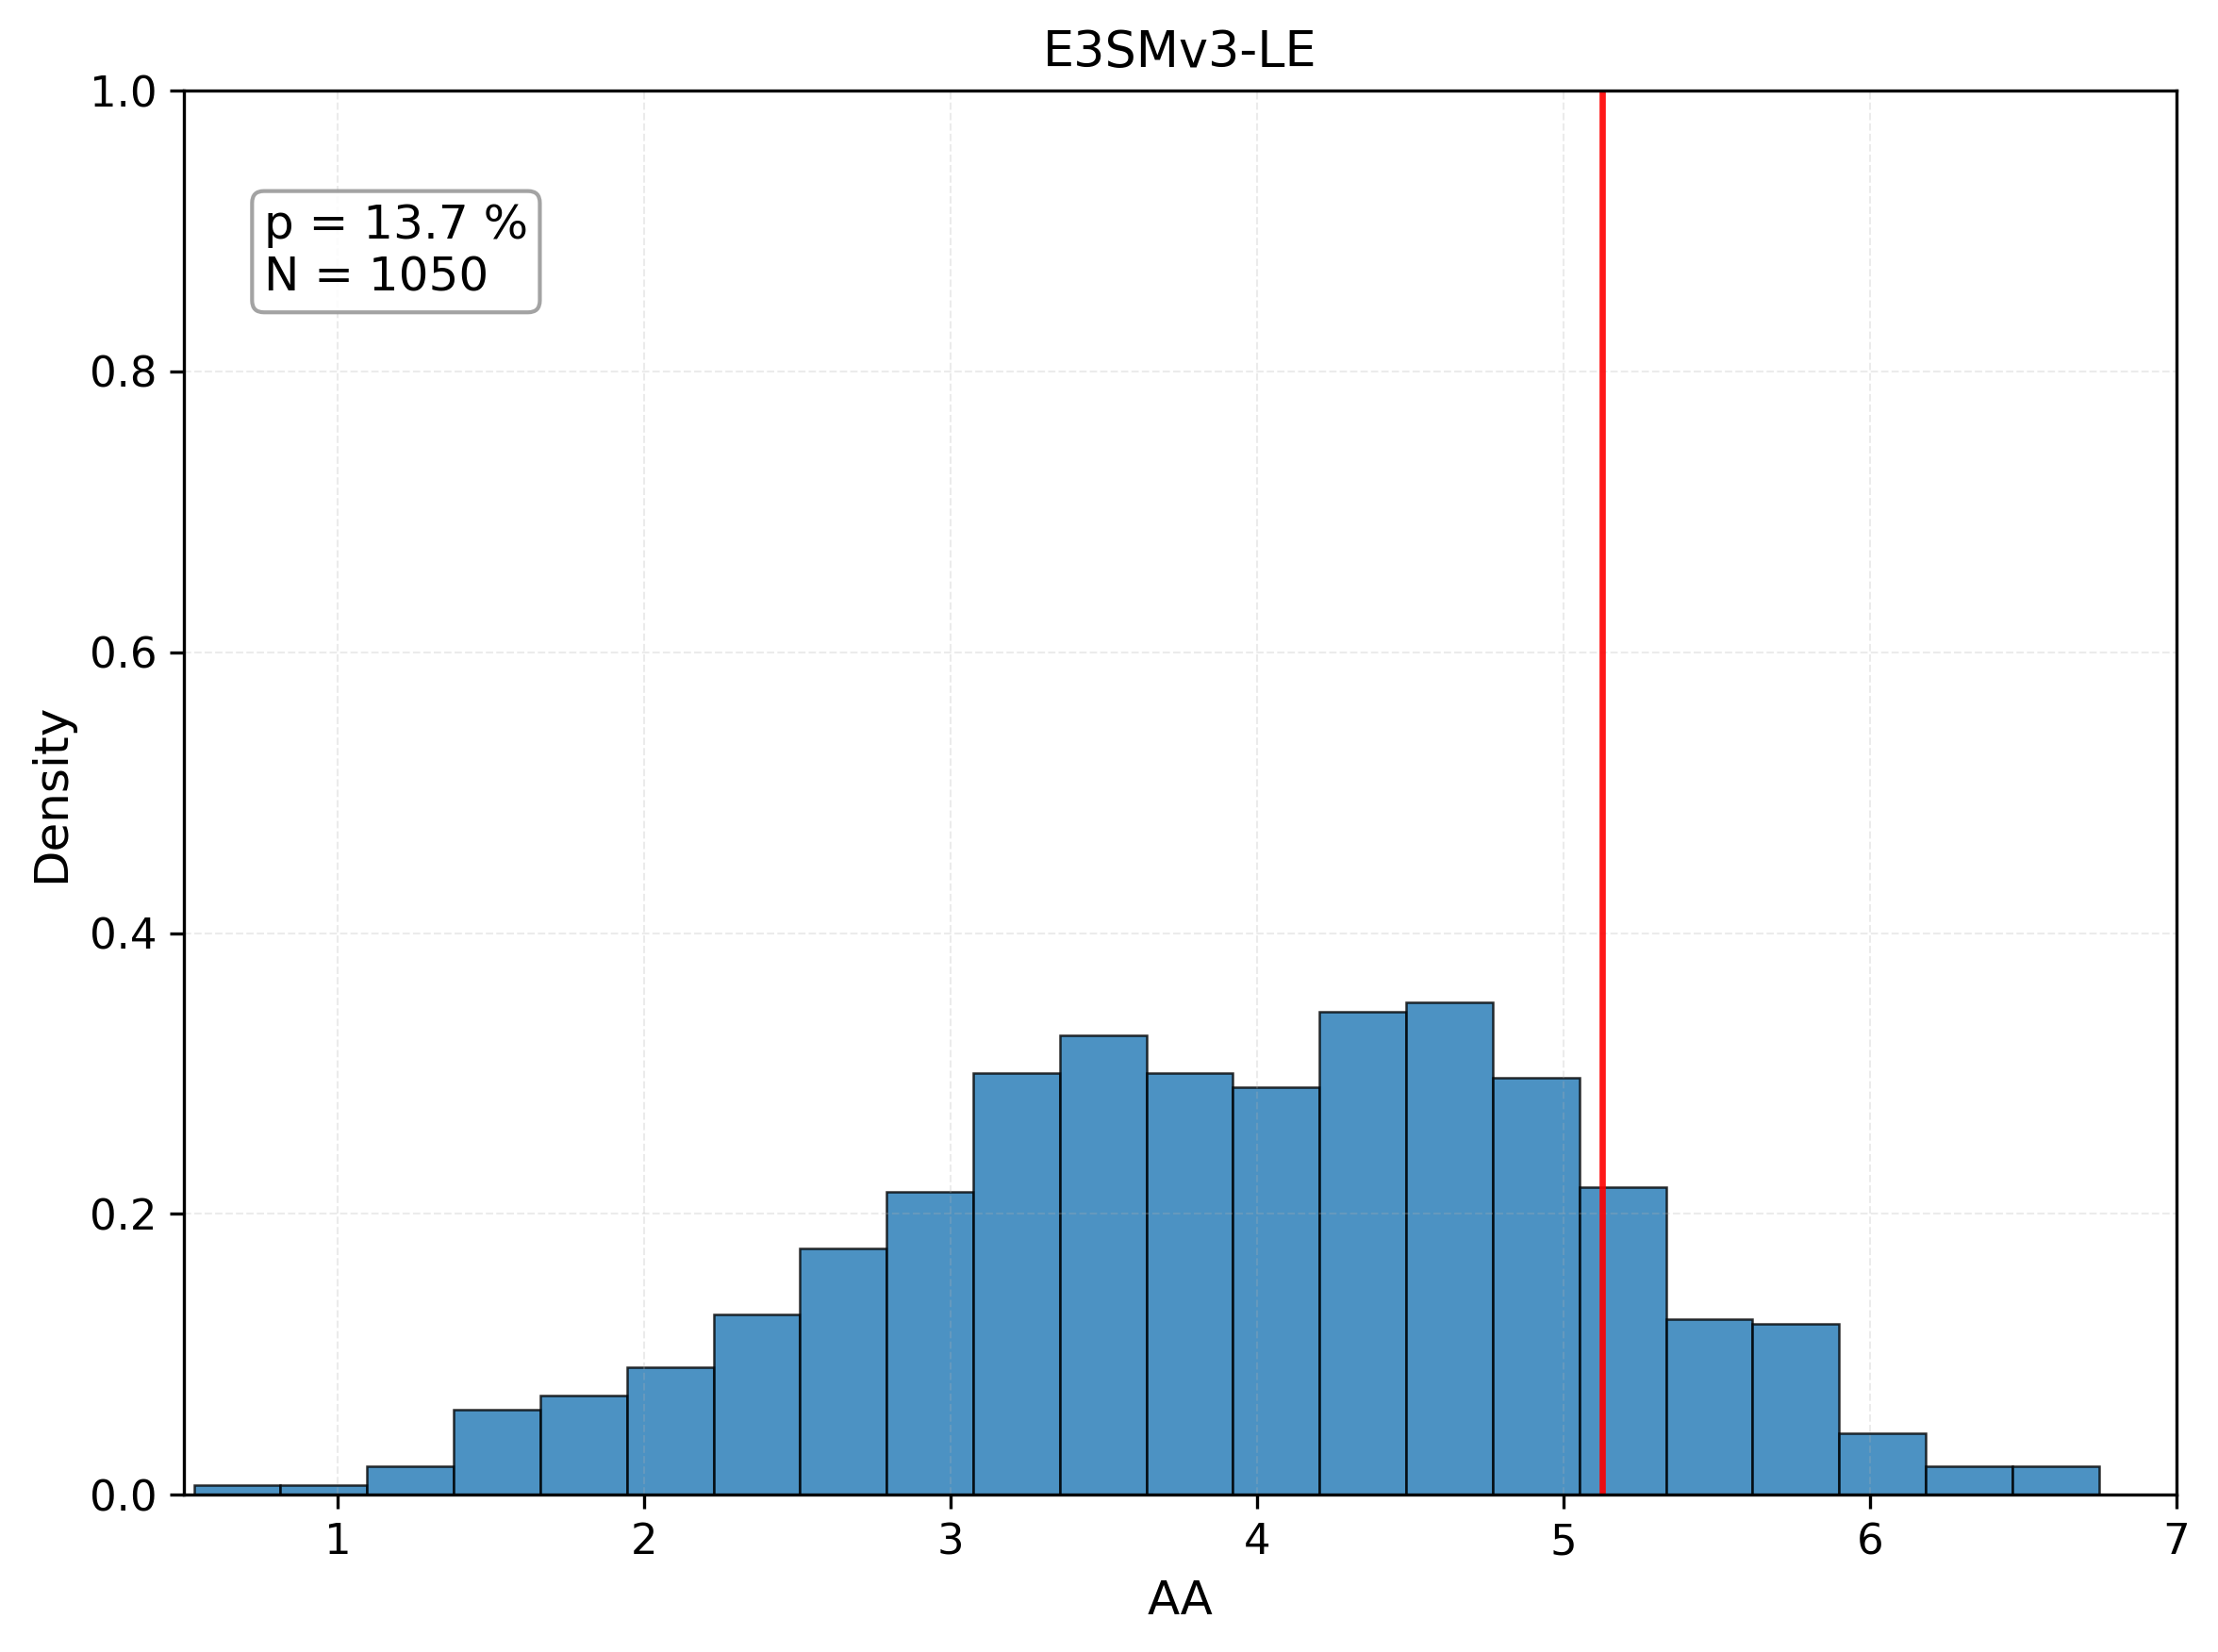

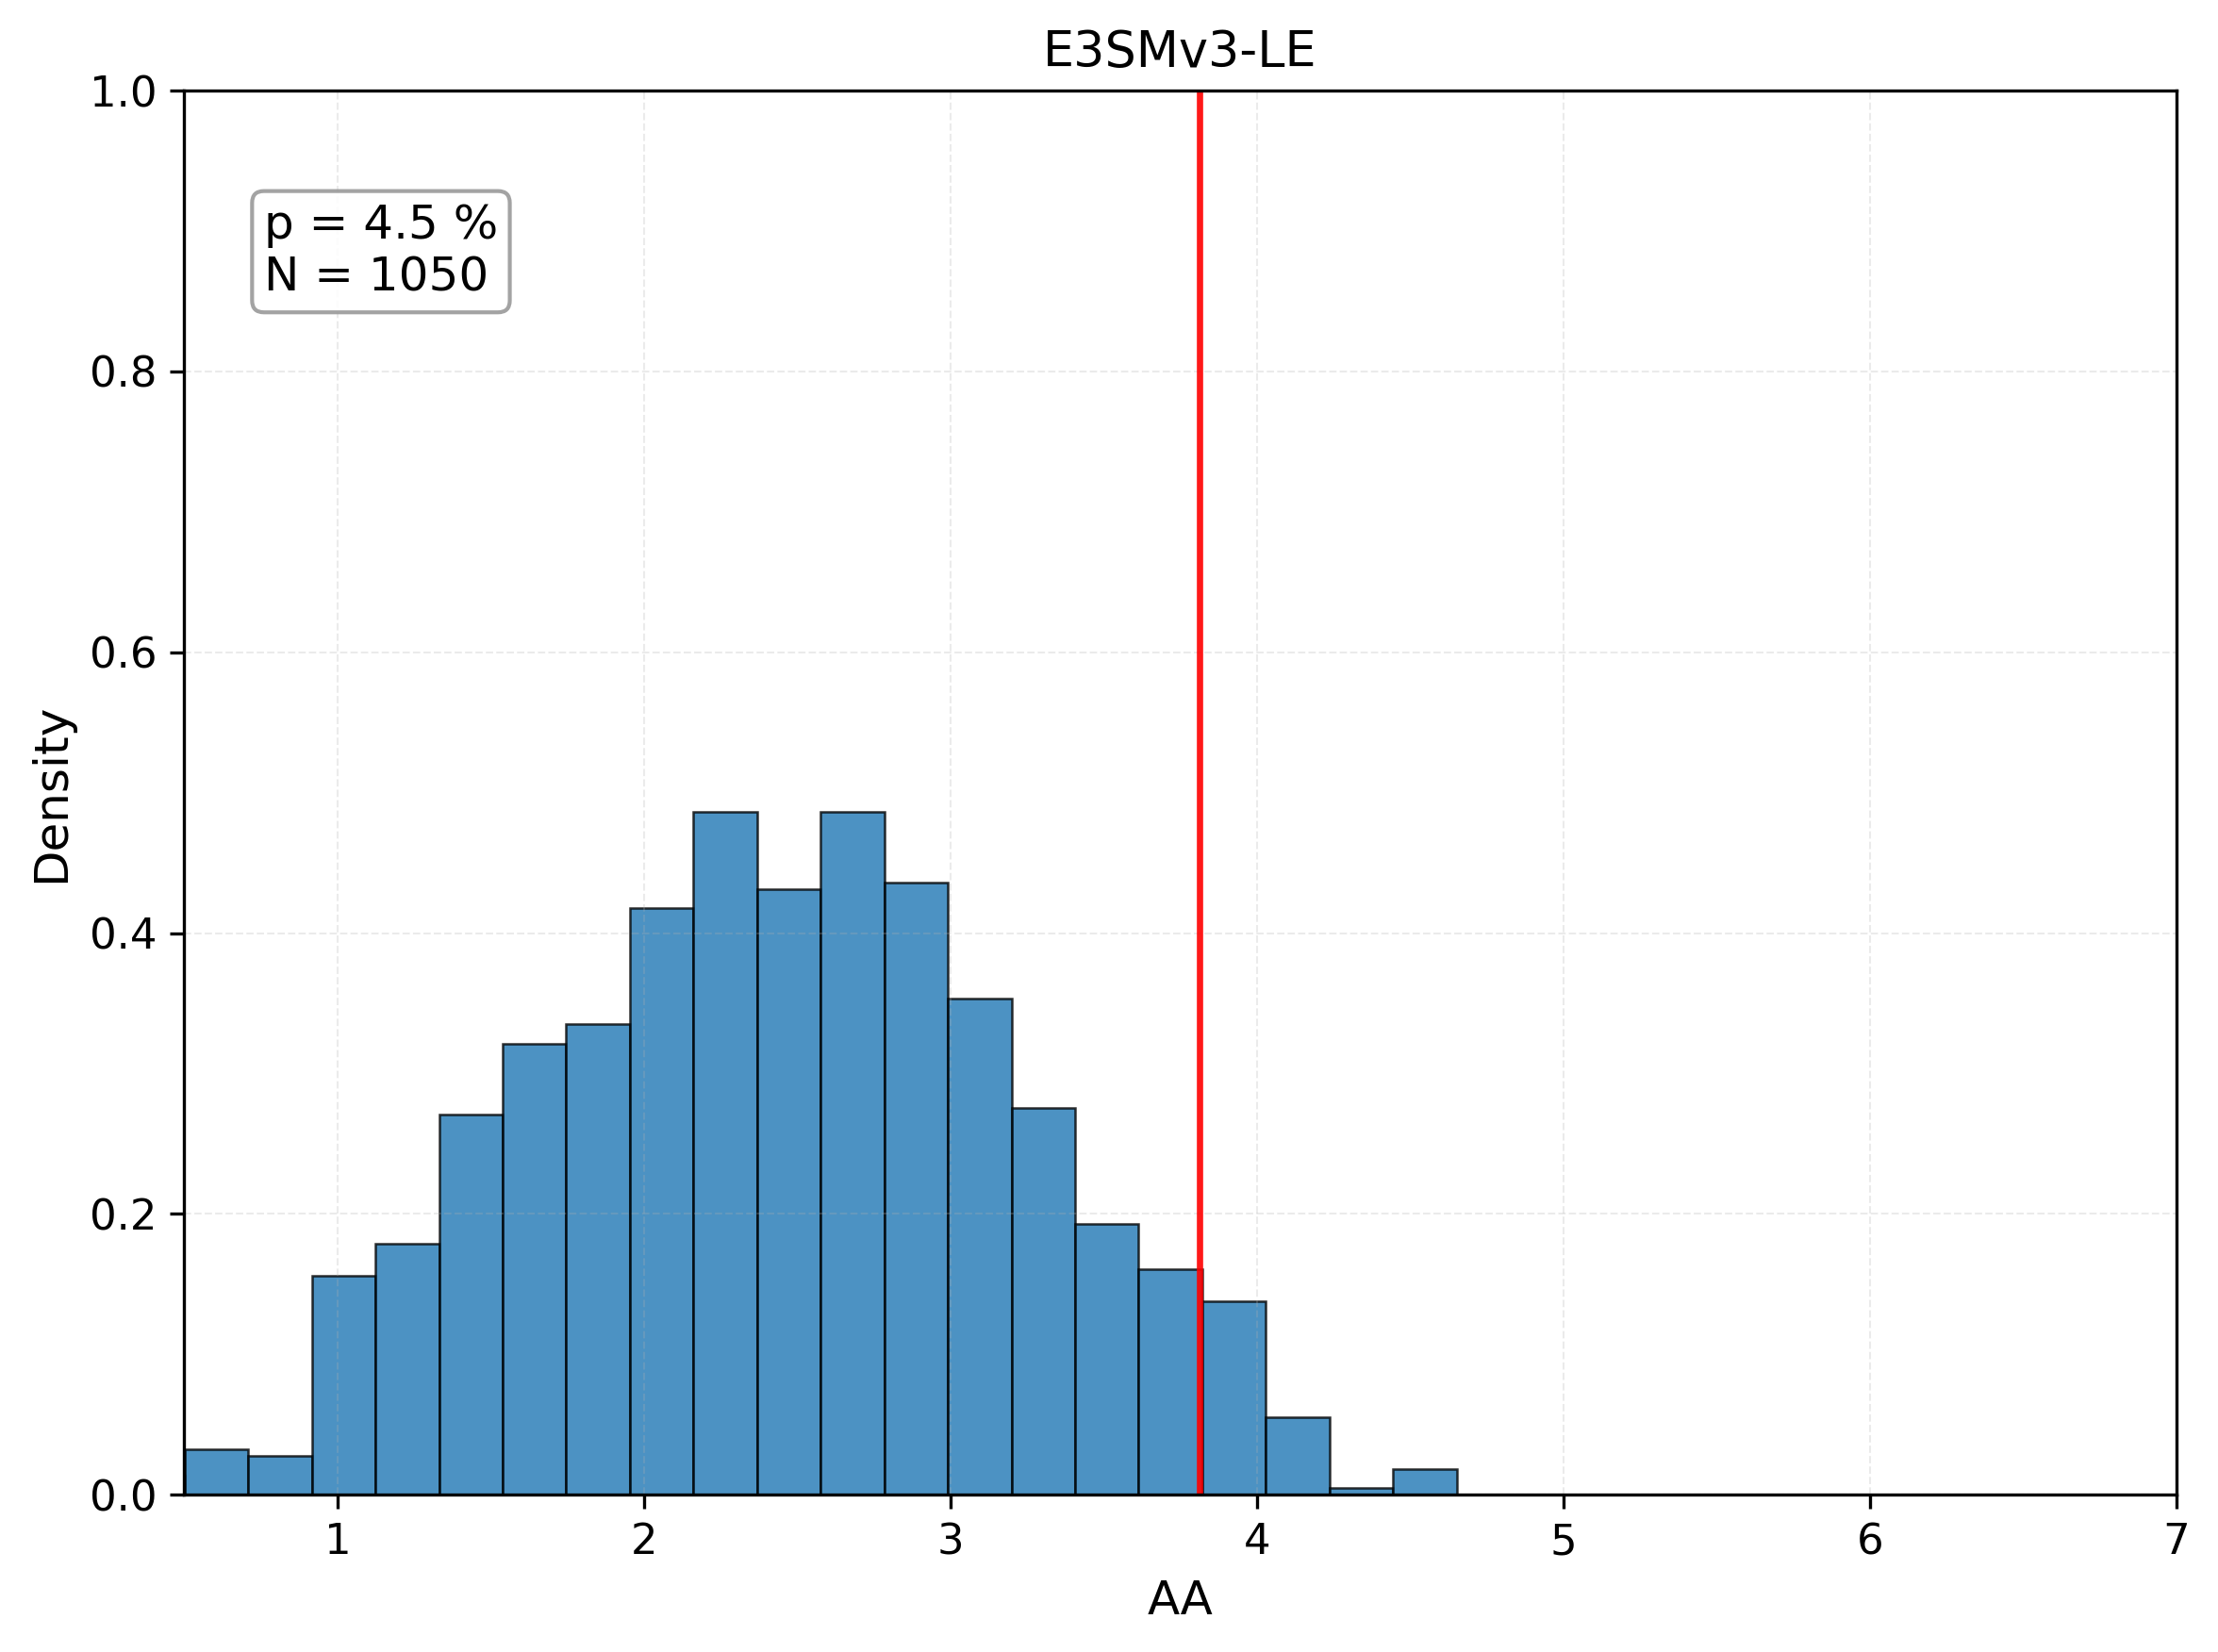

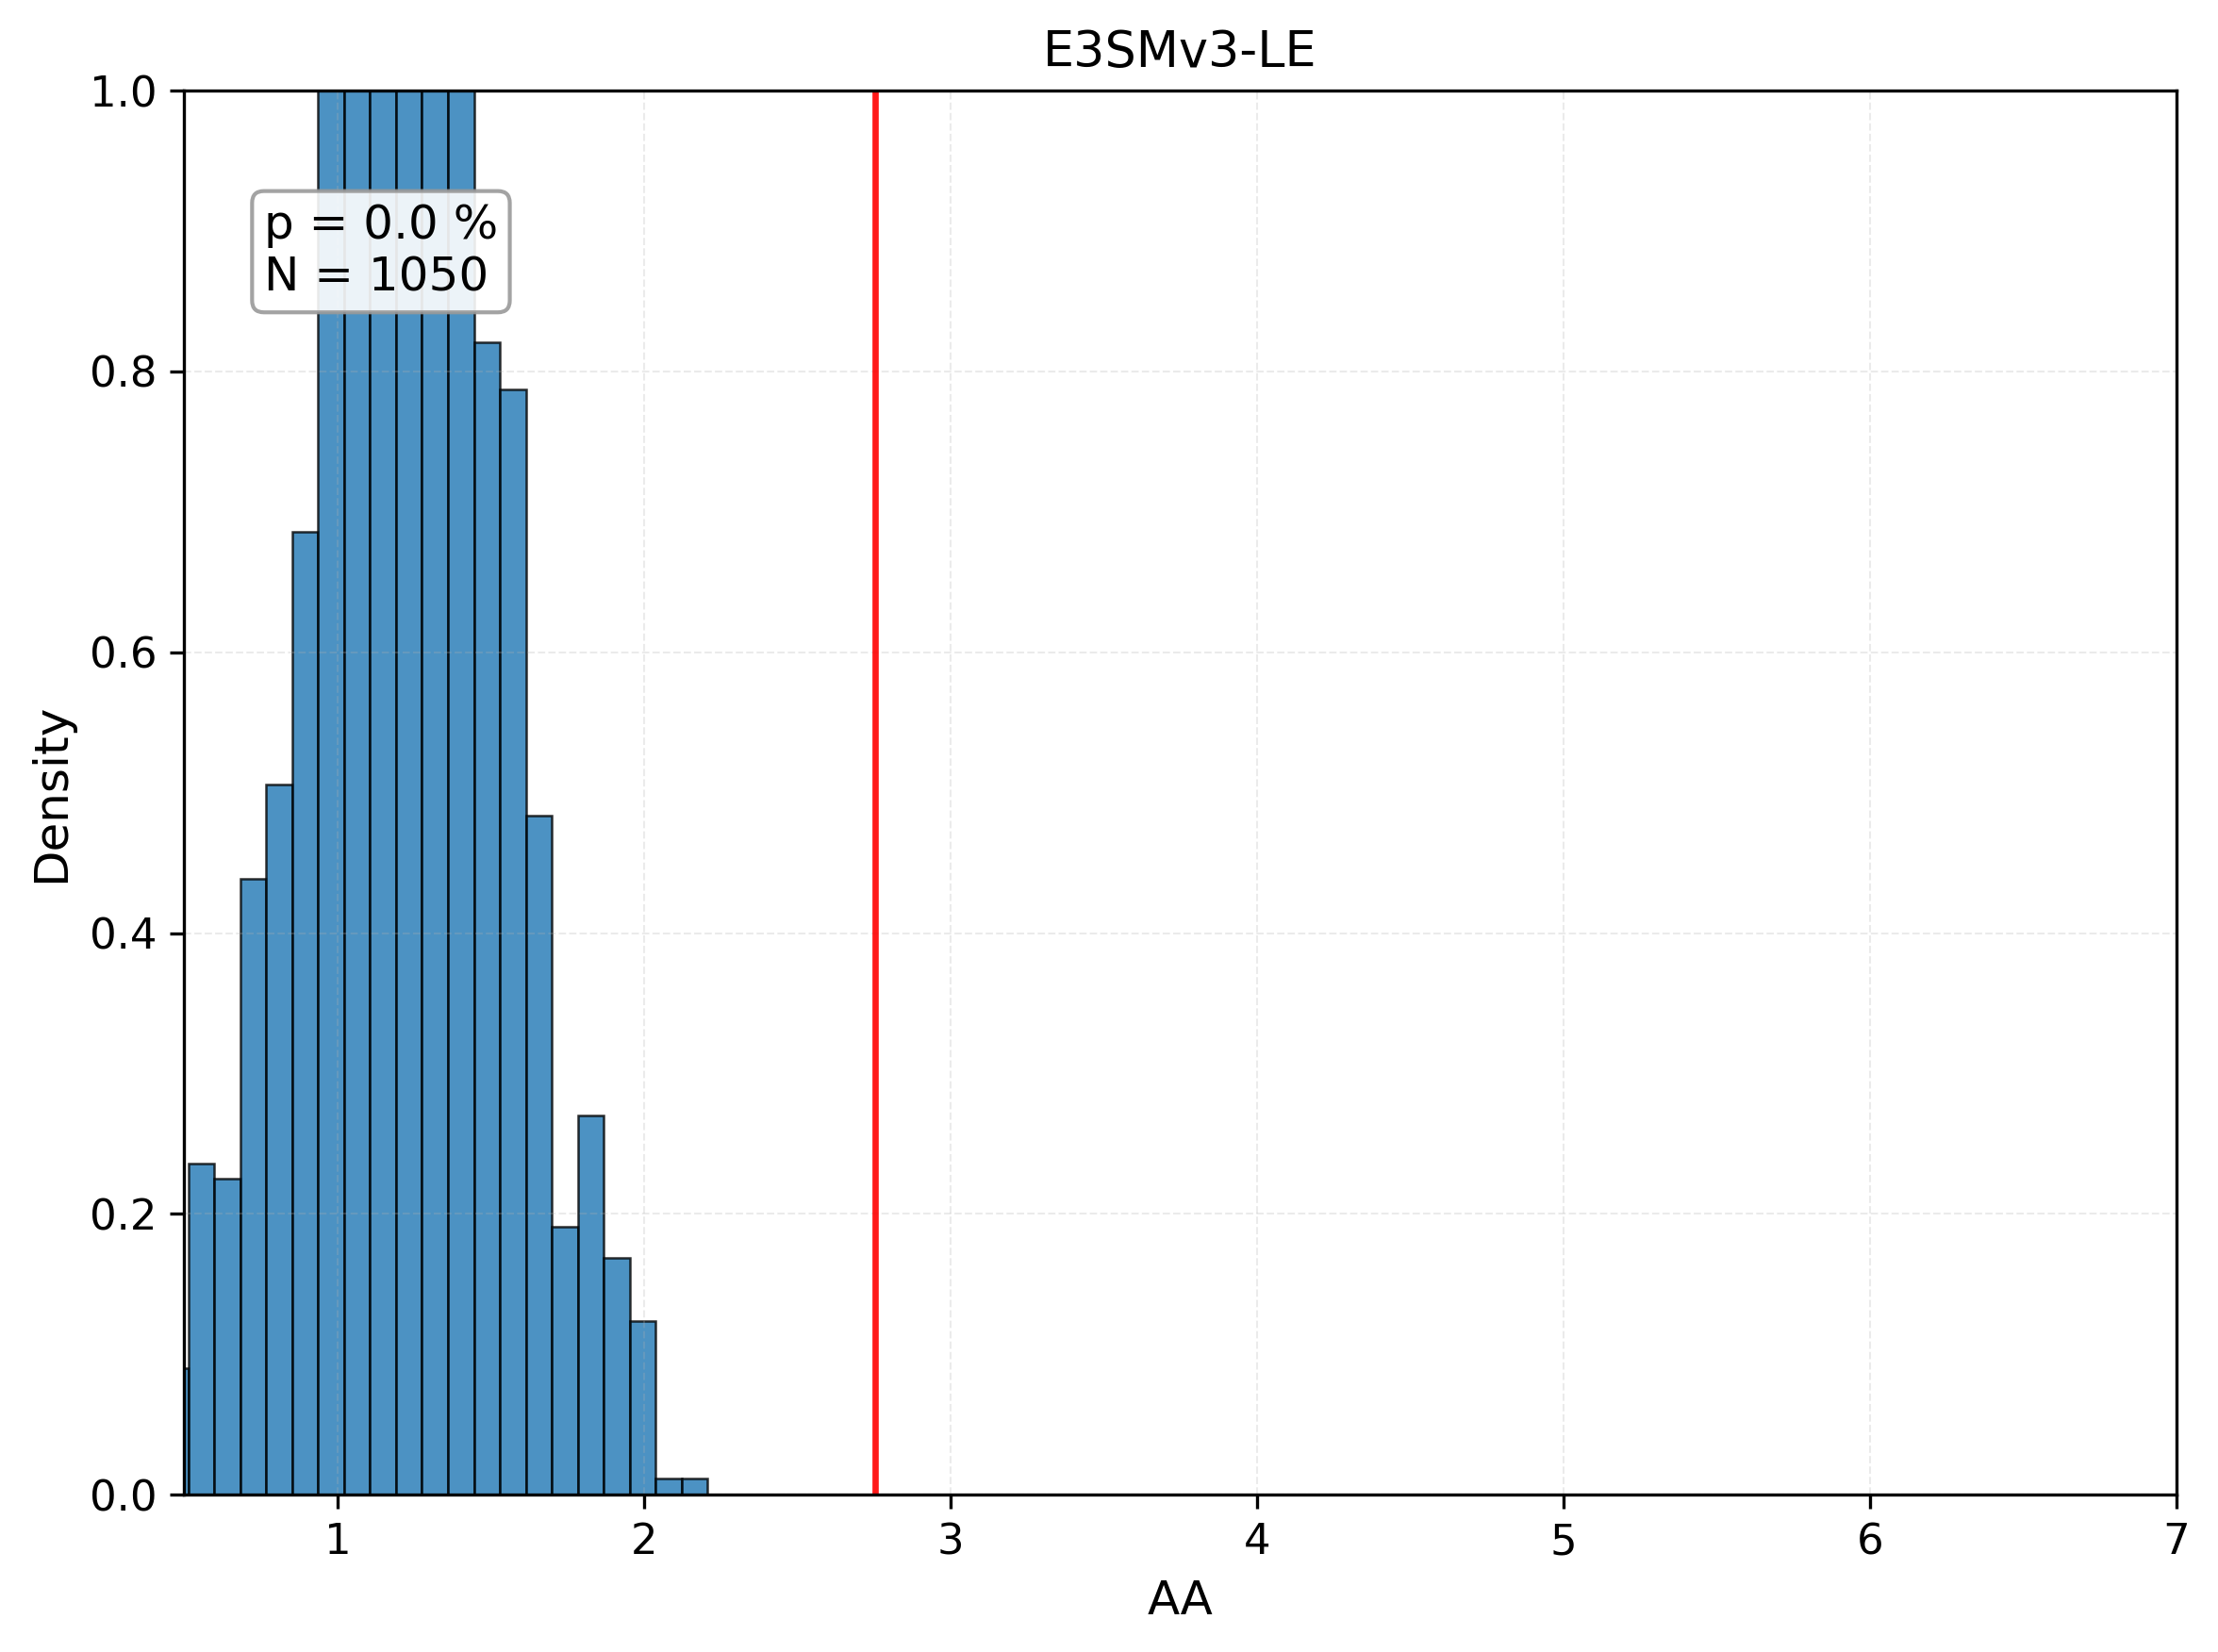

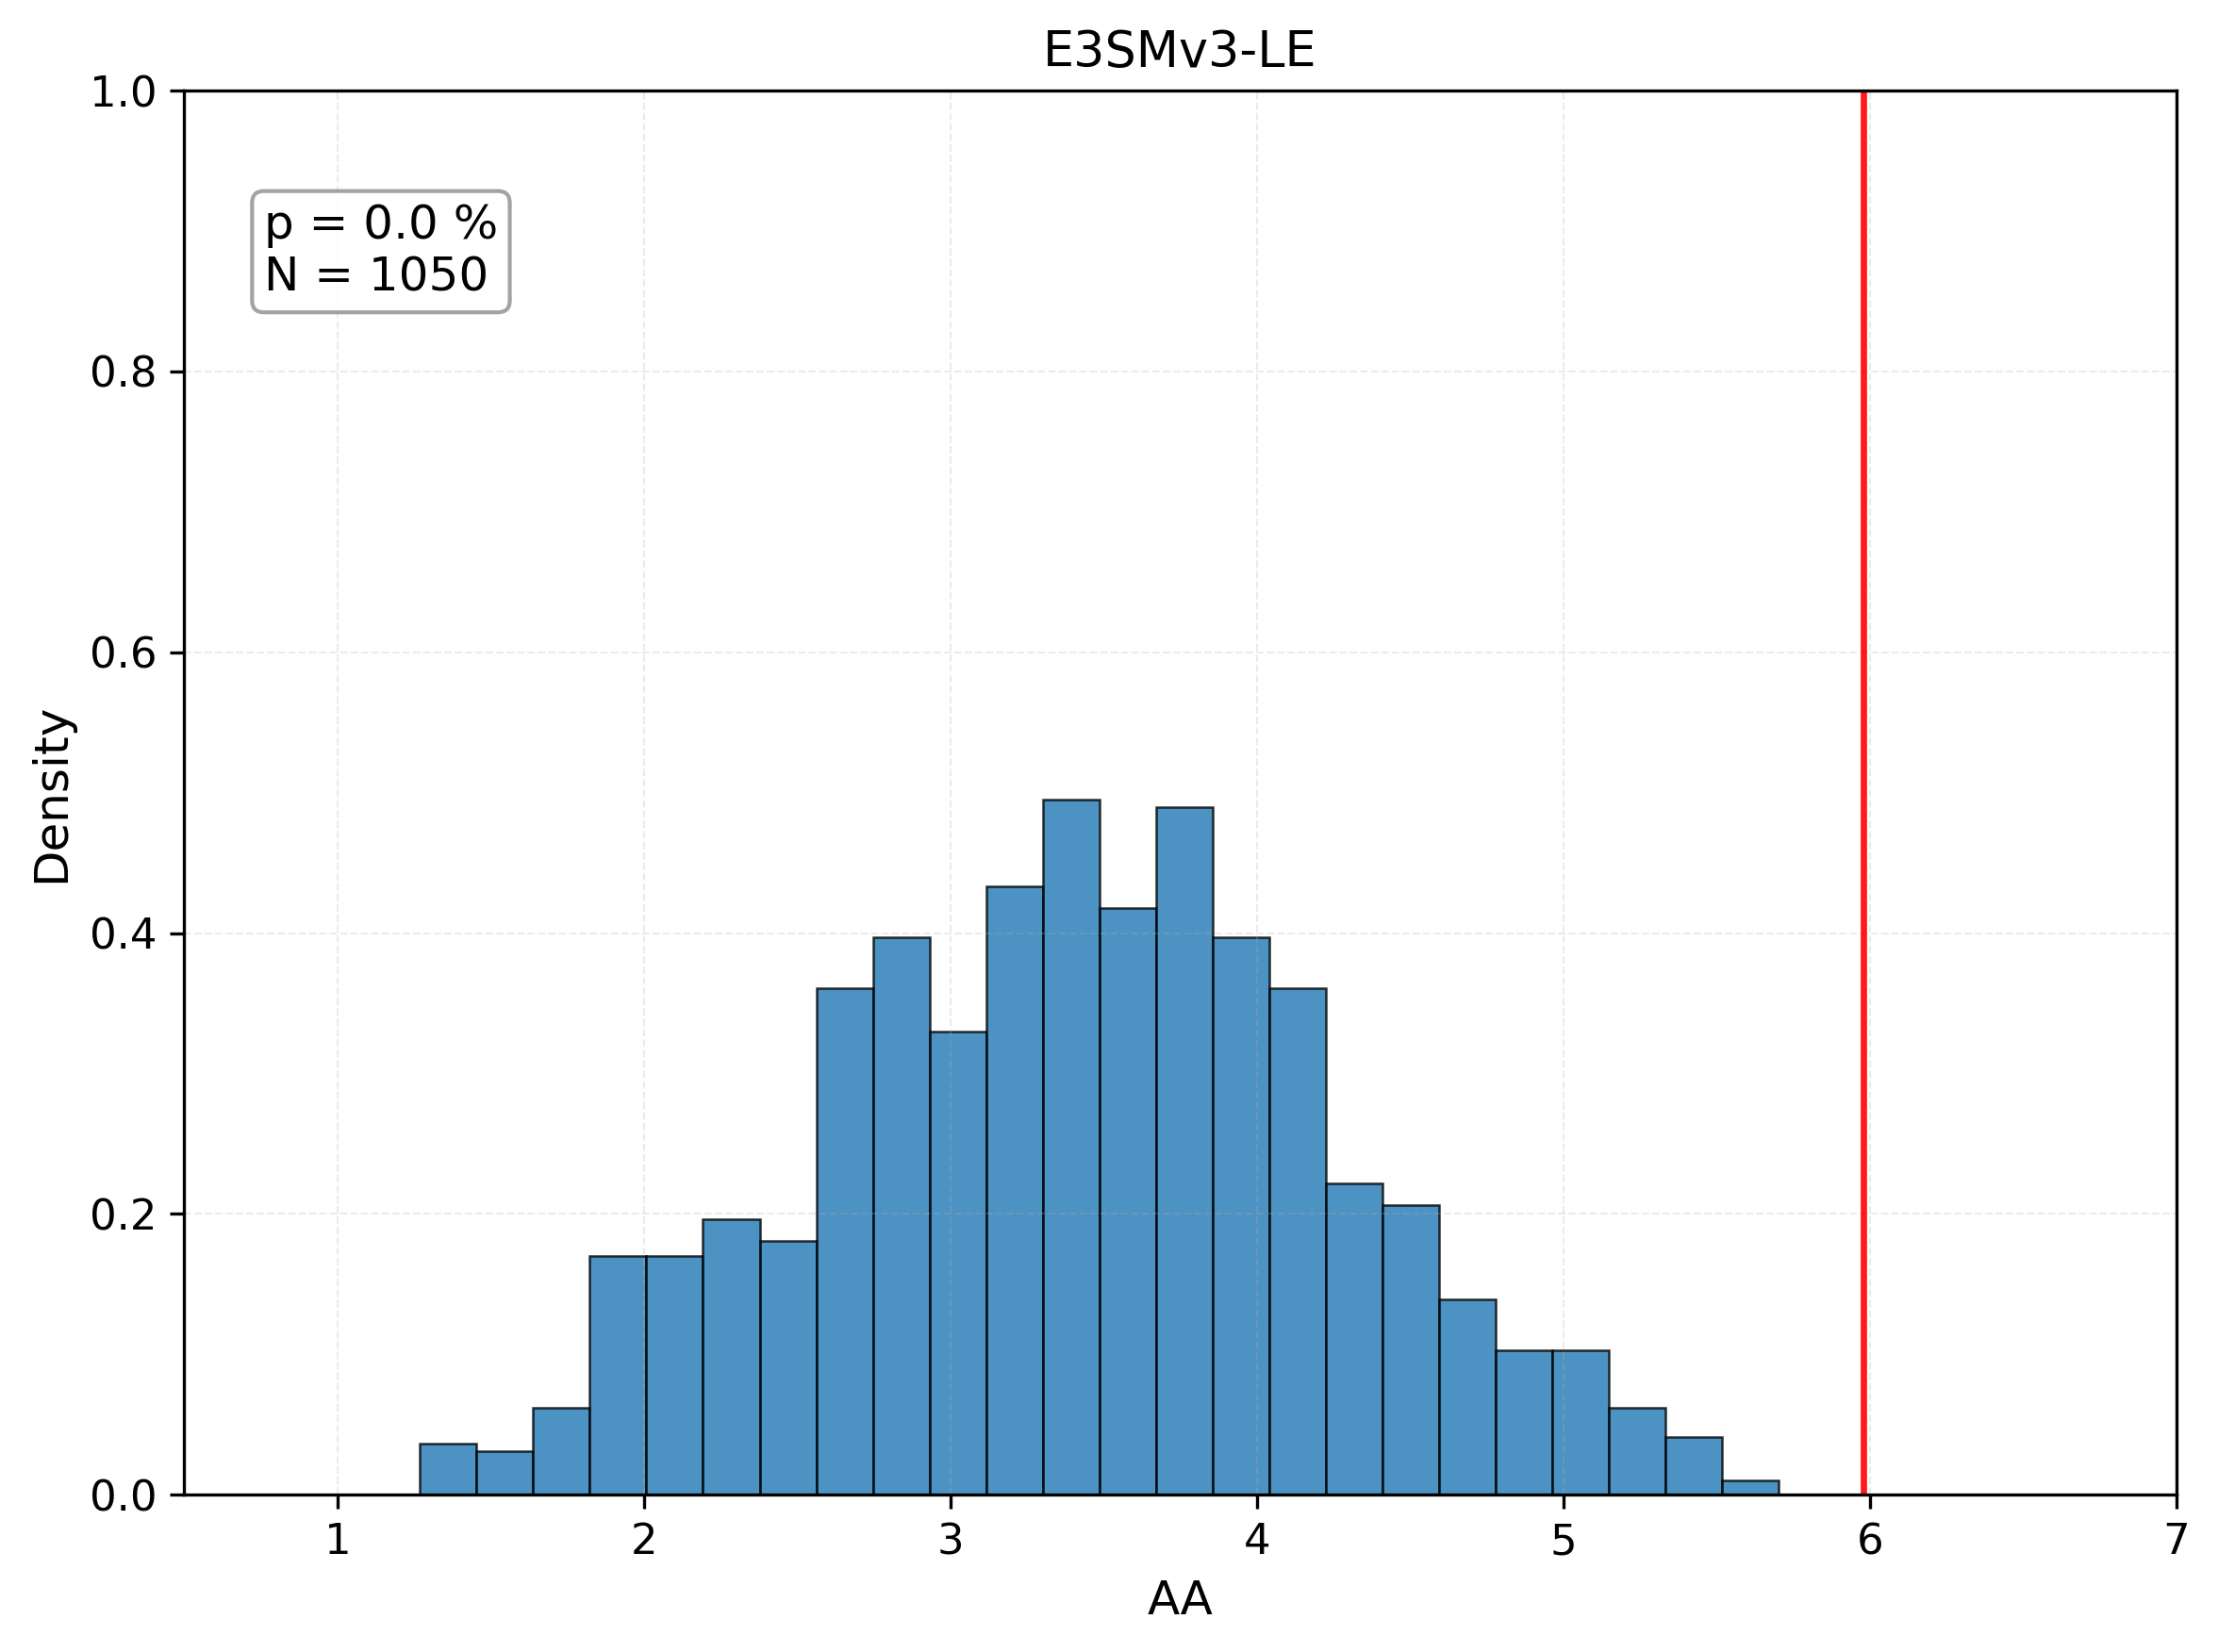

In [7]:
if __name__ == "__main__":
    # ---- paths / constants ----
    OUT_DIR   = DIAG_DIR   # where AA_*.nc/.json live
    os.makedirs(FIG_DIR, exist_ok=True)
    
    region_dict = {
        "arctic": {"name": "Arctic2", "lat_range": (66.5, 90.0),  "lon_range": (-180, 180)},
        "global": {"name": "global", "lat_range": (-90.0, 90.0), "lon_range": (-180, 180)},
    }
    
    VAR          = "TS"
    PTARGT       = (1979, 2050)     # keep consistent with processor outputs
    SEASONS      = ["ANN", "DJF", "MAM", "JJA", "SON"]
    ANCHORS      = ["center", "start", "end"]
    TREND_WINDOW = 30
    
    fontz=12
    dpi=300
    ref_value=2.0                      # fallback if JSON missing
    bins=24 
    xlim=(0.5, 7) 
    ylim=(0, 1.0) 
    density=True
    figsize_per_panel=(8,6)
    anchor = "center"    # overwritten in loop

    # ---- instantiate the PDF plotter ----
    plotter = AAPDFPanelPlotter(
        out_dir=OUT_DIR,
        trend_window=TREND_WINDOW,
        anchor=anchor,   # overwritten in loop
        ptargt=PTARGT,
        fontz=fontz,
        dpi=dpi,
    )

    for anch in ANCHORS:
        plotter.anchor = anch  # used for filename resolution & output suffix

        # Build exact prefixes inline (must match processor naming)
        obs_prefix = f"AA2_driftcorr_ERA5_{anch}_ts_ERA5_{VAR}"
        mod_prefix = f"AA2_driftcorr_E3SMv3-LE_{anch}_ts_v3.LR.historical_{VAR}"
        groups={"E3SMv3-LE": mod_prefix}   # single panel

        for seas in SEASONS:
            # One-panel PDF (since we only have one model group)
            out_basename = f"AA2_driftcorr_pdf_panels_{seas}_{anch}.pdf"
            fig, axes = plotter.plot(
                season=seas,
                groups=groups,   # single panel
                obs_prefix=obs_prefix,               # red line from ERA5 JSON
                ref_value=ref_value,                       # fallback if JSON missing
                bins=bins,
                xlim=xlim,
                ylim=ylim,
                density=density,
                out_name=out_basename,               # plotter writes into OUT_DIR
                figsize_per_panel=figsize_per_panel,
            )

            # Move from OUT_DIR → FIG_DIR (optional, keeps figs together)
            src = os.path.join(OUT_DIR, out_basename.replace(".pdf", f"_{seas}_{anch}.pdf"))
            dst = os.path.join(FIG_DIR, out_basename)
            if os.path.exists(src):
                Path(src).replace(dst)
                print(f"[OK] saved {dst}")
